<a href="https://colab.research.google.com/github/ehigt1/My_PhD_Research_Work/blob/main/PhD_Turbine_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset from your specific path
file_path = "/content/PhD_LNG_System_Dataset_Full.csv"
df = pd.read_csv(file_path)

# Rename columns to match the expected names from generate_and_lock_dataset()
# The original dataset has columns x0 to x6 and u.
# The notebook's downstream cells expect: Mass_Flow_x1, Plenum_Pressure_x2, Rotor_Speed_x3,
# MCHE_Exit_Temp_x4, MR_Exit_Temp_x5, Suction_Pressure_x6, AntiSurge_Valve_x7, Control_Input_u.
# We need to map x0 to Mass_Flow_x1, x1 to Plenum_Pressure_x2, and so on.
# Based on generate_and_lock_dataset: x[:,0] is Mass_Flow_x1, x[:,1] is Plenum_Pressure_x2 etc.
# The input CSV seems to already have this mapping implicitly by column index (e.g. x0 is Mass_Flow_x1).
# Let's verify the columns and map them to the expected names used in the dashboard cells.

# Assuming the order in the CSV matches the logical order from the original generation function
# Original mapping from generate_and_lock_dataset:
# x[:,0] -> 'Mass_Flow_x1' (This is 'x0' in the CSV, but labeled 'Mass_Flow_x1' in the code)
# x[:,1] -> 'Plenum_Pressure_x2' ('x1' in CSV)
# x[:,2] -> 'Rotor_Speed_x3' ('x2' in CSV)
# x[:,3] -> 'MCHE_Exit_Temp_x4' ('x3' in CSV)
# x[:,4] -> 'MR_Exit_Temp_x5' ('x4' in CSV)
# x[:,5] -> 'Suction_Pressure_x6' ('x5' in CSV)
# x[:,6] -> 'AntiSurge_Valve_x7' ('x6' in CSV)
# u -> 'Control_Input_u' ('u' in CSV)

# Correct column names as per dashboard code
new_column_names = {
    'x0': 'Mass_Flow_x1',
    'x1': 'Plenum_Pressure_x2',
    'x2': 'Rotor_Speed_x3',
    'x3': 'MCHE_Exit_Temp_x4',
    'x4': 'MR_Exit_Temp_x5',
    'x5': 'Suction_Pressure_x6',
    'x6': 'AntiSurge_Valve_x7',
    'u': 'Control_Input_u'
}
df = df.rename(columns=new_column_names)

# Add 'Time Step (k)' column as index for time-series analysis
df['Time Step (k)'] = np.arange(len(df))

# Calculate 'Safety_Margin_h_x' and 'Status' based on original generation logic
# This logic should reflect the `generate_and_lock_dataset` function's calculations
# m_surge = 0.32 + 0.18 * x[:, 1] + 0.08 * x[:, 2] (using original x indices, which are now df column names)
# x[:, 0] is now 'Mass_Flow_x1'
# x[:, 1] is now 'Plenum_Pressure_x2'
# x[:, 2] is now 'Rotor_Speed_x3'
m_surge = 0.32 + 0.18 * df['Plenum_Pressure_x2'] + 0.08 * df['Rotor_Speed_x3']
df['Safety_Margin_h_x'] = df['Mass_Flow_x1'] - m_surge
df['Status'] = np.where(df['Safety_Margin_h_x'] < 0, 'SURGE VIOLATION', 'SAFE')

# Now, the DataFrame 'df' is ready with the correct columns and derived values.

# 2. Print the Header (First 10 rows)
print("--- DATASET HEAD (First 10 Rows) ---")
print(df.head(10).to_string())

# 3. Print the Tail (Last 10 rows)
print("\n--- DATASET TAIL (Last 10 Rows) ---")
print(df.tail(10).to_string())

# 4. Print Statistical Summary (Crucial for your PhD documentation)
print("\n--- STATISTICAL SUMMARY (Objectives 2 & 7) ---")
print(df.describe().to_string())

--- DATASET HEAD (First 10 Rows) ---
   Mass_Flow_x1  Plenum_Pressure_x2  Rotor_Speed_x3  MCHE_Exit_Temp_x4  MR_Exit_Temp_x5  Suction_Pressure_x6  AntiSurge_Valve_x7  Control_Input_u  Time Step (k)  Safety_Margin_h_x Status
0      0.500000            0.500000        0.500000           0.500000         0.500000             0.500000            0.500000            0.000              0           0.050000   SAFE
1      0.499530            0.499561        0.499432           0.499588         0.499508             0.499589            0.499517            0.001              1           0.049654   SAFE
2      0.499088            0.499160        0.498874           0.499140         0.498980             0.499155            0.499086            0.002              2           0.049329   SAFE
3      0.498543            0.498608        0.498392           0.498604         0.498453             0.498659            0.498529            0.003              3           0.048922   SAFE
4      0.498111            0

### Check for Missing Values and Anomalies

In [2]:
print("\n--- MISSING VALUES (Objectives 2 & 7) ---")
print(df.isnull().sum())


--- MISSING VALUES (Objectives 2 & 7) ---
Mass_Flow_x1           0
Plenum_Pressure_x2     0
Rotor_Speed_x3         0
MCHE_Exit_Temp_x4      0
MR_Exit_Temp_x5        0
Suction_Pressure_x6    0
AntiSurge_Valve_x7     0
Control_Input_u        0
Time Step (k)          0
Safety_Margin_h_x      0
Status                 0
dtype: int64


The `df.isnull().sum()` output shows that there are no missing values in any of the columns. This means the dataset is complete in terms of entries for each variable. Now, let's visualize the missing data patterns to further confirm this and get a clearer picture.

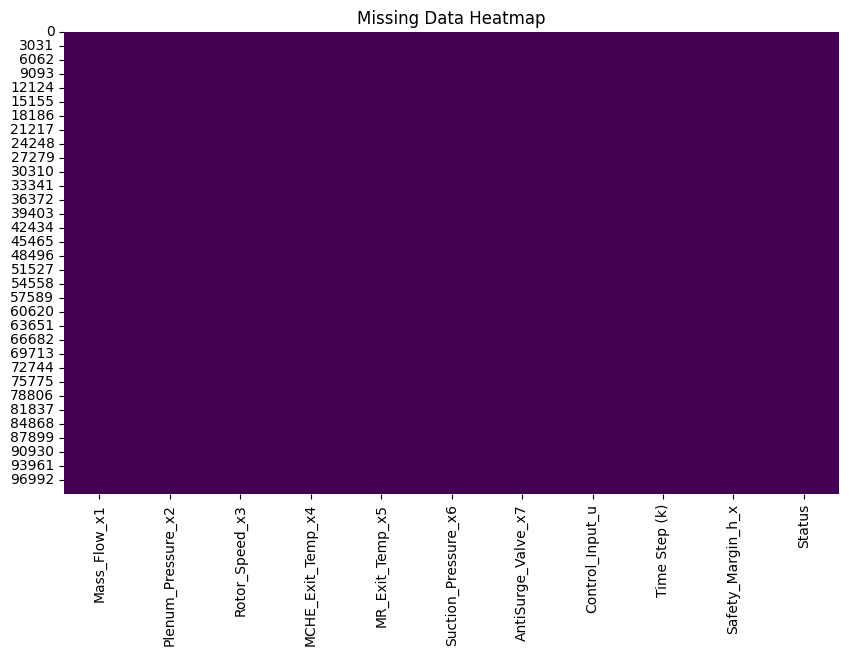

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

### Box Plots for Outlier Detection

Box plots are excellent tools for visualizing the distribution of numerical data and identifying potential outliers. An outlier is typically defined as a data point that falls outside of 1.5 times the interquartile range (IQR) from the first or third quartile.

Below, we will generate a box plot for each column in the `df` DataFrame to inspect their distributions and spot any anomalies.

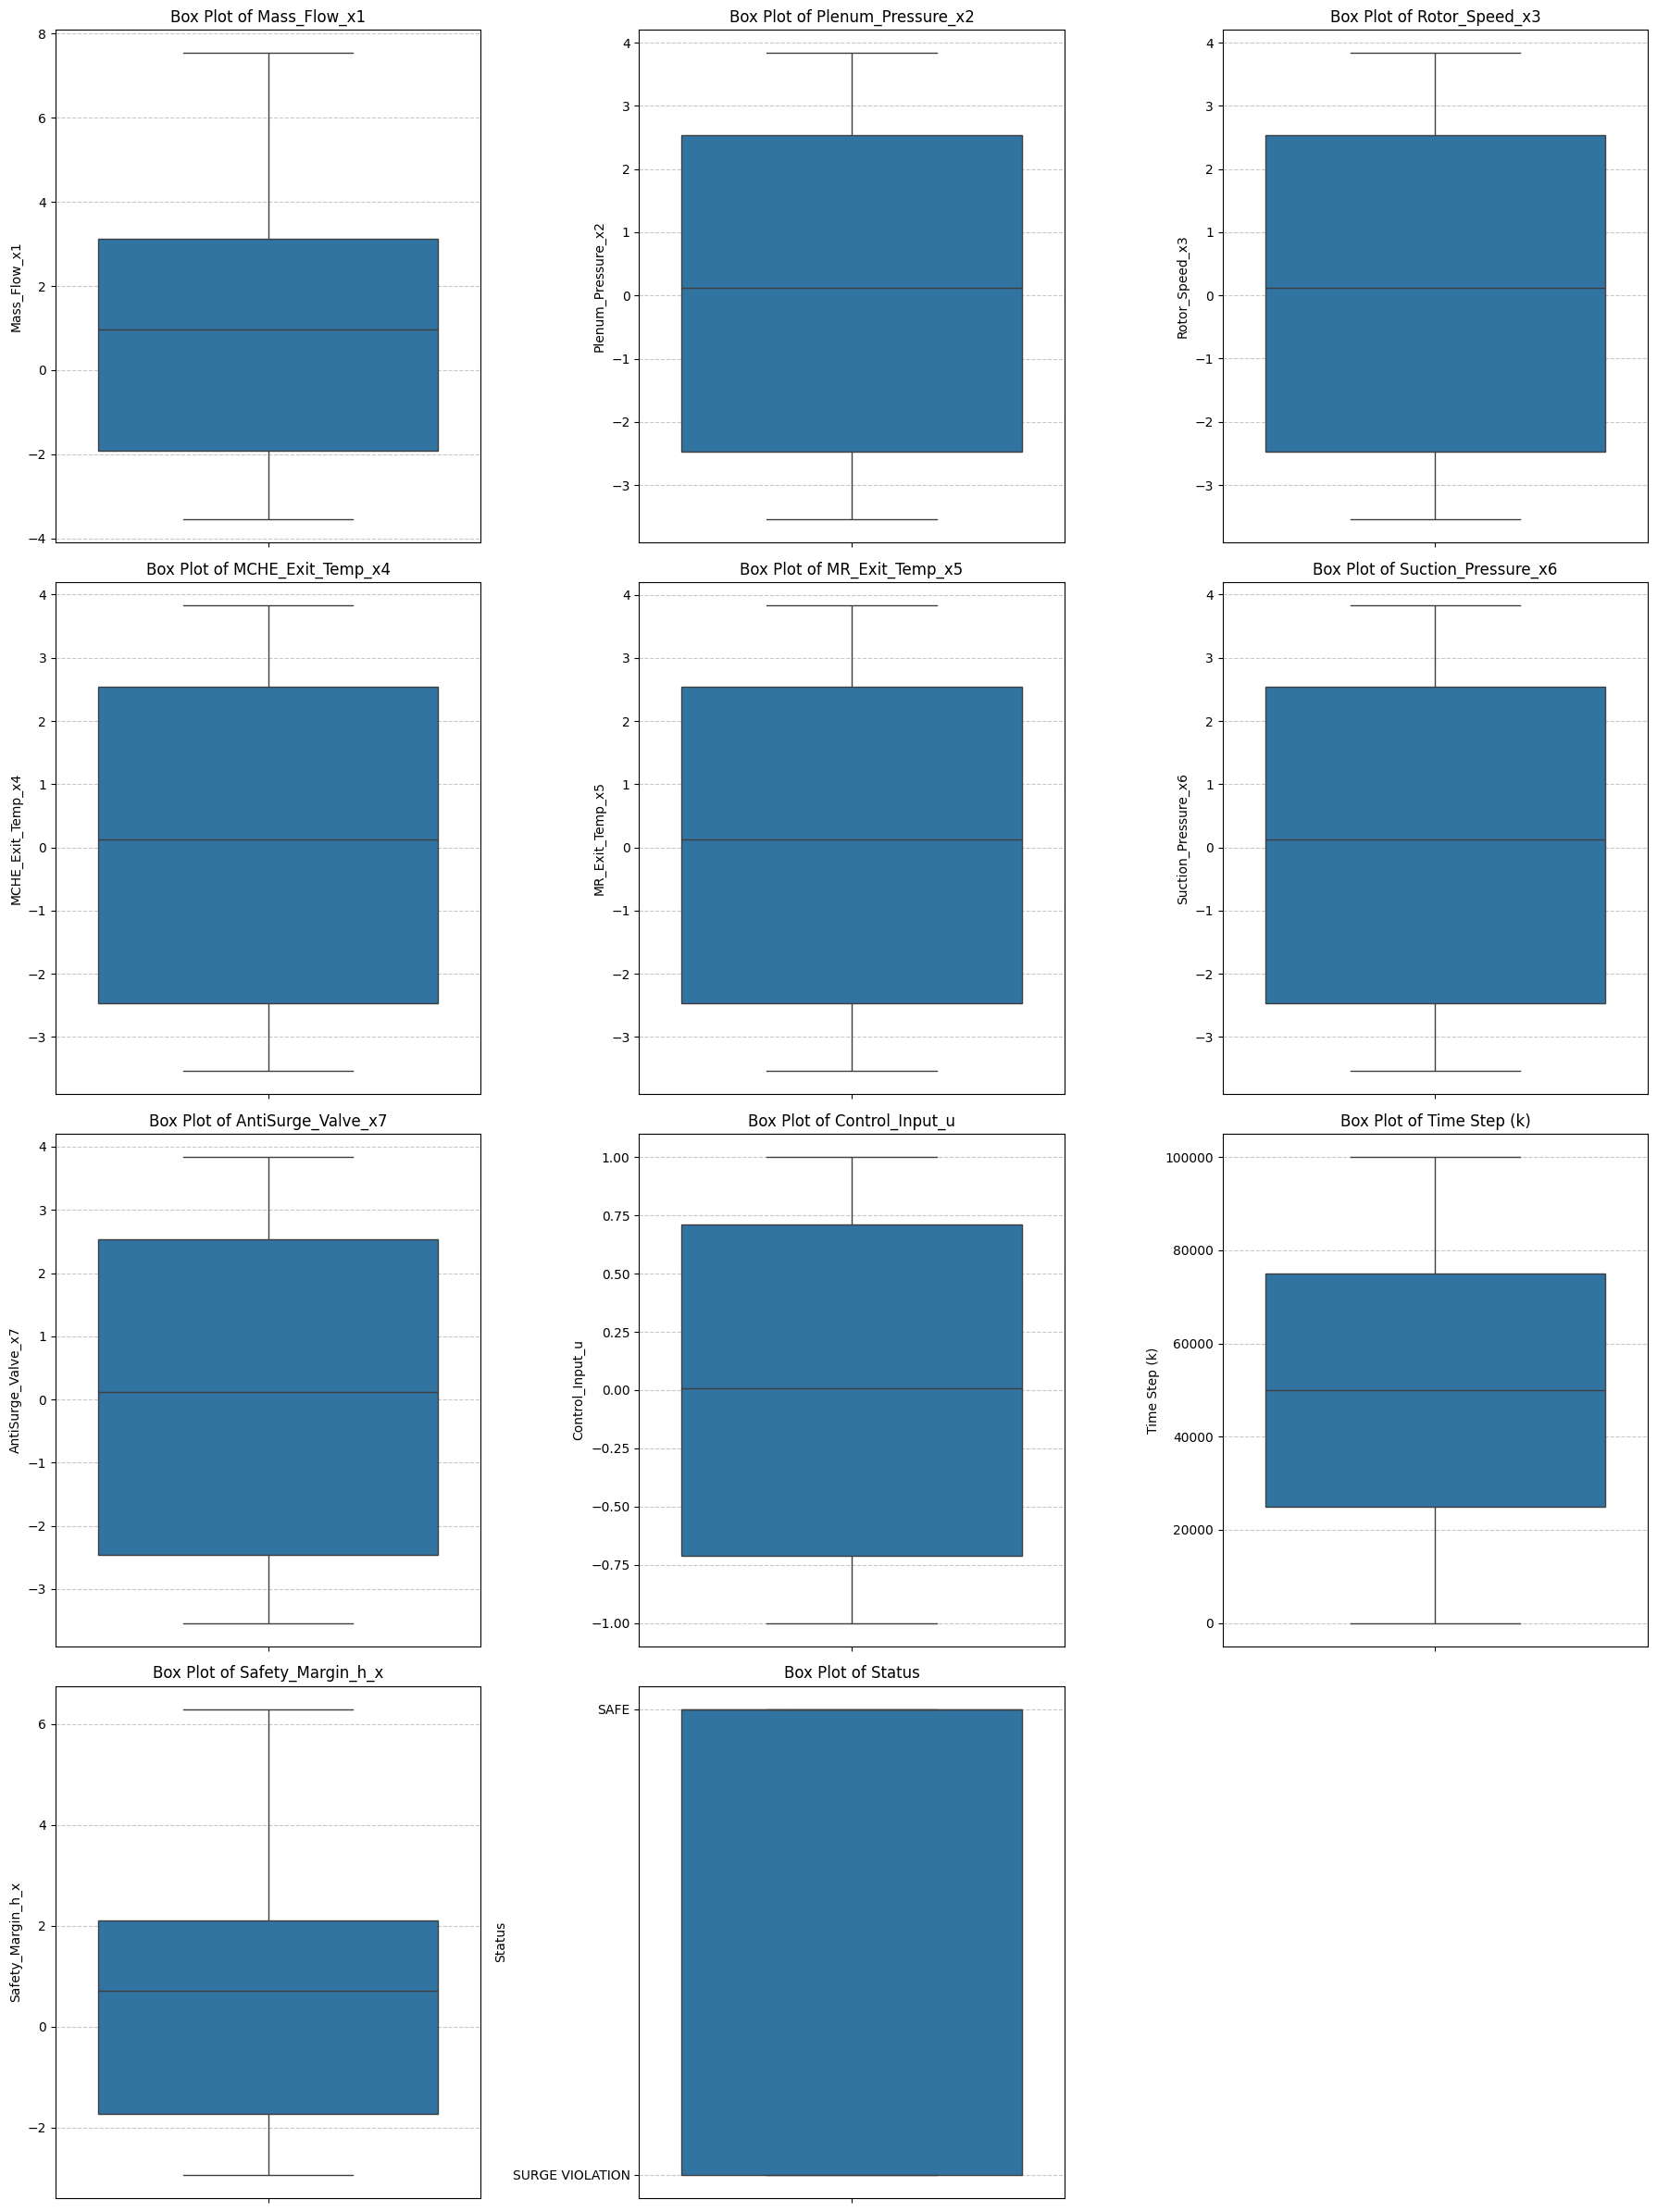

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all column names from the DataFrame
columns = df.columns

# Determine the number of rows and columns for the subplot grid
num_cols = len(columns)
num_rows = (num_cols + 2) // 3  # Aim for 3 columns per row, adjust for remainder

plt.figure(figsize=(18, num_rows * 6)) # Adjust figure size dynamically

for i, col in enumerate(columns):
    plt.subplot(num_rows, 3, i + 1) # Create subplot
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Distribution of Safety Margin ($h(x)$) for Risk Profile Analysis

To analyze the system's risk profile, it's crucial to understand the distribution of the `Safety_Margin_h_x`. This plot will show the frequency of different safety margin values, helping to identify how often the system operates near or below the critical surge line ($h(x) = 0$). A Kernel Density Estimate (KDE) will also be overlaid to provide a smoothed representation of the distribution.

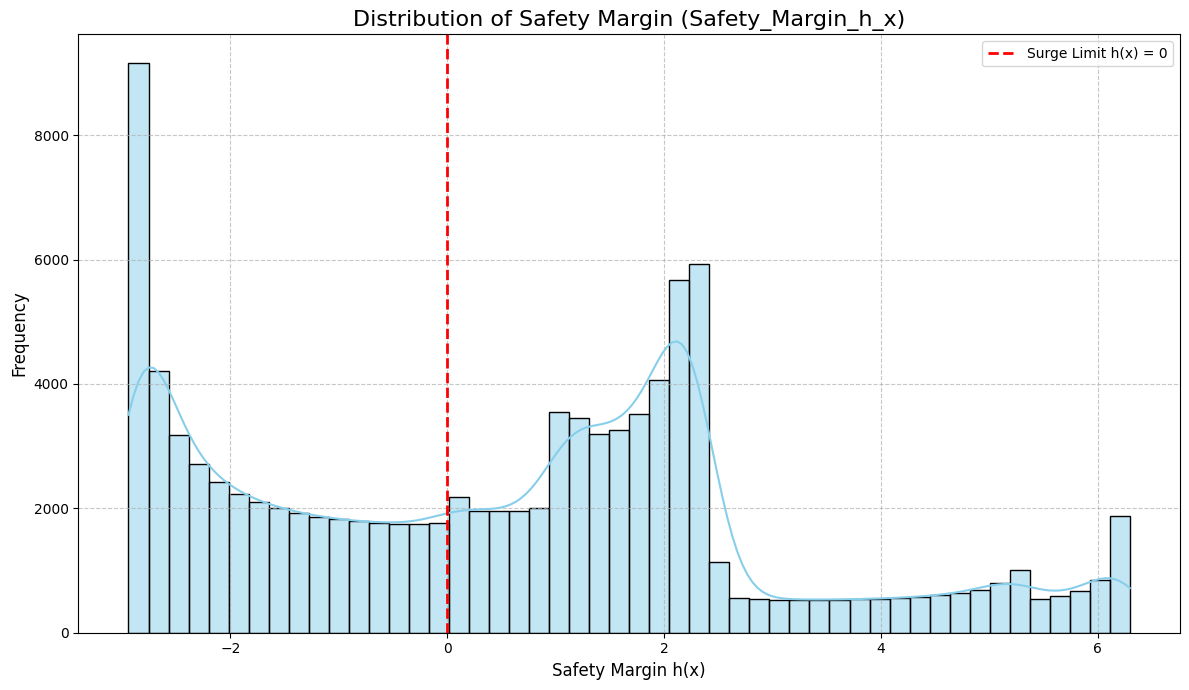

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.histplot(df['Safety_Margin_h_x'], kde=True, color='skyblue', bins=50) # Use histplot for both histogram and KDE
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Surge Limit h(x) = 0')
plt.title('Distribution of Safety Margin (Safety_Margin_h_x)', fontsize=16)
plt.xlabel('Safety Margin h(x)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Analysis: Control Input vs. Safety Margin

Understanding the relationship between the `Control_Input_u` and the `Safety_Margin_h_x` is vital for developing effective control strategies and ensuring system safety. This analysis will help determine if changes in the control input have a discernible and quantifiable impact on the safety margin. A scatter plot with a regression line will visually represent this relationship, and the Pearson correlation coefficient will provide a statistical measure of their linear association.

Pearson Correlation between Control_Input_u and Safety_Margin_h_x: 0.5531


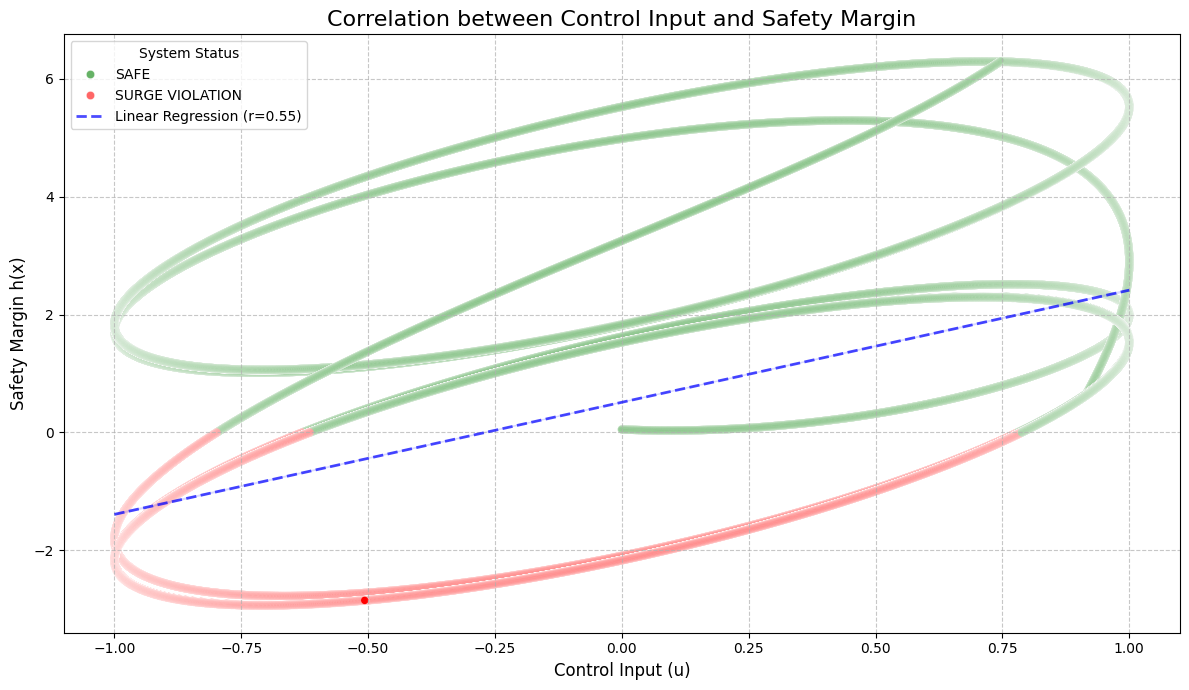

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation coefficient
correlation = df['Control_Input_u'].corr(df['Safety_Margin_h_x'])
print(f"Pearson Correlation between Control_Input_u and Safety_Margin_h_x: {correlation:.4f}")

plt.figure(figsize=(12, 7))
sns.scatterplot(x=df['Control_Input_u'], y=df['Safety_Margin_h_x'], alpha=0.6, hue=df['Status'], palette={'SAFE': 'green', 'SURGE VIOLATION': 'red'})
sns.regplot(x=df['Control_Input_u'], y=df['Safety_Margin_h_x'], scatter=False, color='blue', line_kws={'linestyle':'--', 'alpha':0.7, 'linewidth':2}, label=f'Linear Regression (r={correlation:.2f})')
plt.title('Correlation between Control Input and Safety Margin', fontsize=16)
plt.xlabel('Control Input (u)', fontsize=12)
plt.ylabel('Safety Margin h(x)', fontsize=12)
plt.legend(title='System Status')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Pearson Correlation between Rotor_Speed_x3 and Mass_Flow_x1: 0.8532


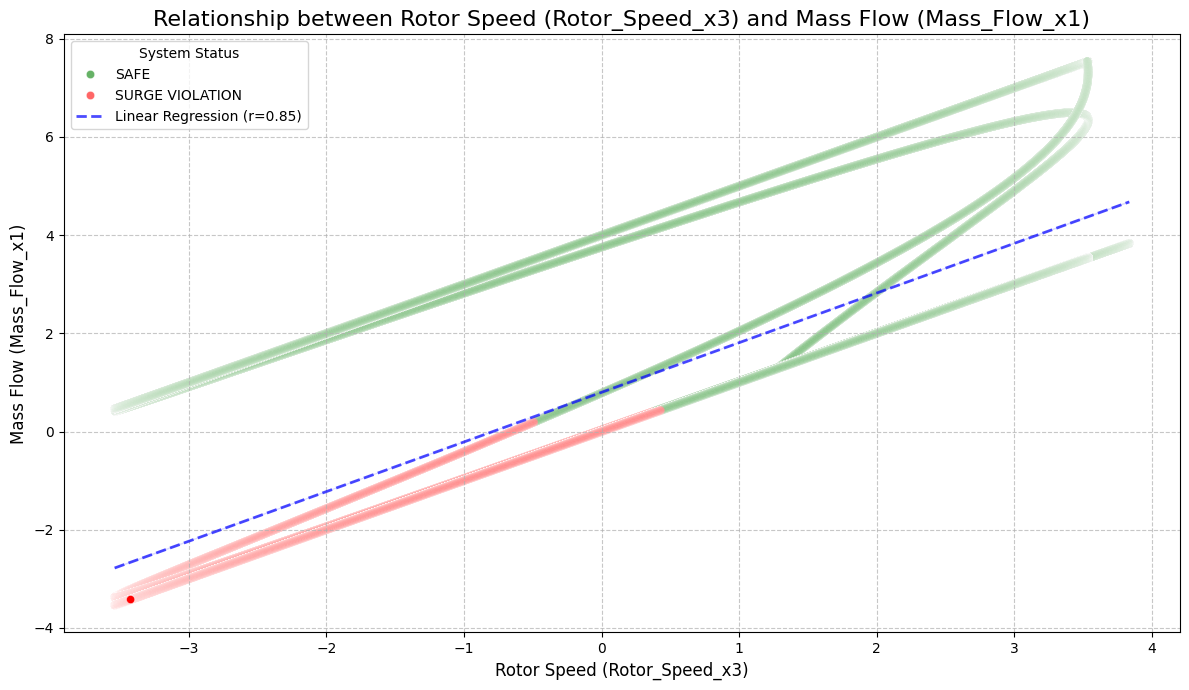

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation coefficient between Rotor_Speed_x3 and Mass_Flow_x1
correlation_rotor_mass = df['Rotor_Speed_x3'].corr(df['Mass_Flow_x1'])
print(f"Pearson Correlation between Rotor_Speed_x3 and Mass_Flow_x1: {correlation_rotor_mass:.4f}")

plt.figure(figsize=(12, 7))
sns.scatterplot(x=df['Rotor_Speed_x3'], y=df['Mass_Flow_x1'], alpha=0.6, hue=df['Status'], palette={'SAFE': 'green', 'SURGE VIOLATION': 'red'})
sns.regplot(x=df['Rotor_Speed_x3'], y=df['Mass_Flow_x1'], scatter=False, color='blue', line_kws={'linestyle':'--', 'alpha':0.7, 'linewidth':2}, label=f'Linear Regression (r={correlation_rotor_mass:.2f})')
plt.title('Relationship between Rotor Speed (Rotor_Speed_x3) and Mass Flow (Mass_Flow_x1)', fontsize=16)
plt.xlabel('Rotor Speed (Rotor_Speed_x3)', fontsize=12)
plt.ylabel('Mass Flow (Mass_Flow_x1)', fontsize=12)
plt.legend(title='System Status')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Implementing a Robust Machine Learning Model (RandomForestRegressor)

Given the characteristics of the dataset, especially the intentionally injected FDI attack creating outliers in `x0`, selecting a machine learning model that is robust to such anomalies is crucial. Tree-based models, such as `RandomForestRegressor`, was chosen because they are generally less sensitive to outliers compared to linear models because they make decisions based on feature splits rather than distance calculations or assumptions about data distribution.

The steps is as follows:
1.  Prepare the data by defining features (inputs) and the target variable (`x0`).
2.  Split the data into training and testing sets.
3.  Train a `RandomForestRegressor` model.
4.  Evaluate its performance using metrics like Mean Absolute Error (MAE) and R-squared.
5.  Visualize the model's predictions against the actual values, specifically highlighting the period where the FDI attack was active, to observe its robustness.

Training set shape: (80000, 7)
Testing set shape: (20000, 7)

Model Evaluation on Test Set:
  Mean Absolute Error (MAE): 1.2144
  R-squared (R2): 0.7024


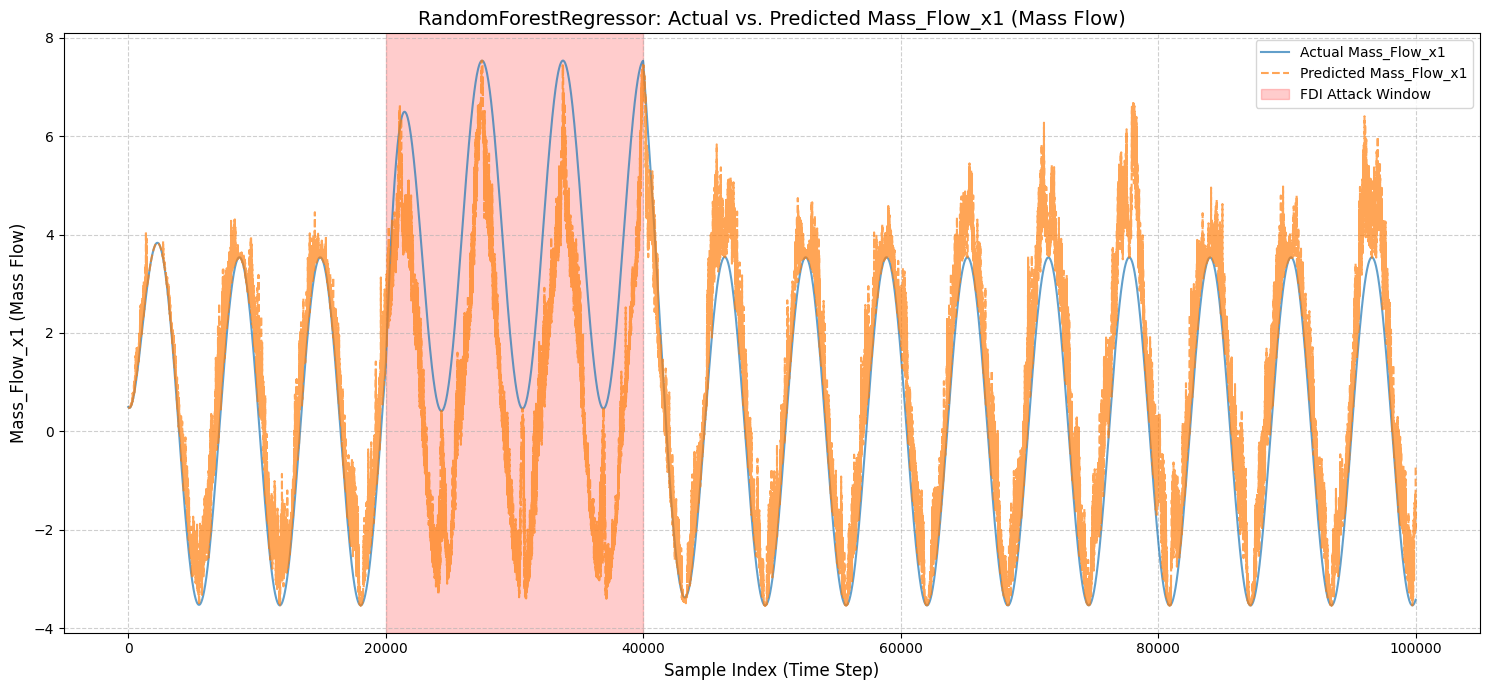

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Define features (X) and target (y)
# We'll use the renamed columns to predict 'Mass_Flow_x1'
features = [
    'Plenum_Pressure_x2',
    'Rotor_Speed_x3',
    'MCHE_Exit_Temp_x4',
    'MR_Exit_Temp_x5',
    'Suction_Pressure_x6',
    'AntiSurge_Valve_x7',
    'Control_Input_u'
]
X = df[features]
y = df['Mass_Flow_x1']

# Split the data into training and testing sets
# We'll use a standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train the RandomForestRegressor
# n_estimators: number of trees in the forest
# random_state for reproducibility
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Set:")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  R-squared (R2): {r2:.4f}")

# --- Visualization of Actual vs. Predicted values ---
# To make the plot more meaningful for time-series data and the FDI attack
# we will recreate the full time index for the test set predictions.
# We need the original index to align predictions with the original time steps.

# Get the original indices of the test set rows
test_indices = X_test.index

# Create a Series for actual and predicted values, aligned by original index
y_test_full = y.loc[test_indices]
y_pred_full = pd.Series(y_pred, index=test_indices)

# Sort by index to maintain time order for plotting
y_test_full = y_test_full.sort_index()
y_pred_full = y_pred_full.sort_index()

# Define the attack window based on the dataset generation logic (samples 20000 to 40000 for x0)
attack_start = 20000
attack_end = 40000

plt.figure(figsize=(15, 7))
plt.plot(y_test_full.index, y_test_full, label='Actual Mass_Flow_x1', alpha=0.7, linewidth=1.5)
plt.plot(y_pred_full.index, y_pred_full, label='Predicted Mass_Flow_x1', alpha=0.7, linestyle='--', linewidth=1.5)

# Highlight the attack window
plt.axvspan(attack_start, attack_end, color='red', alpha=0.2, label='FDI Attack Window')

plt.title('RandomForestRegressor: Actual vs. Predicted Mass_Flow_x1 (Mass Flow)', fontsize=14)
plt.xlabel('Sample Index (Time Step)', fontsize=12)
plt.ylabel('Mass_Flow_x1 (Mass Flow)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- DESCRIPTIVE STATISTICS FOR DF ---")
display(df.describe())

In [9]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

print(f"\nAdditional Model Evaluation Metrics:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")


Additional Model Evaluation Metrics:
  Mean Squared Error (MSE): 2.6108
  Root Mean Squared Error (RMSE): 1.6158


### Implementing a Robust Machine Learning Model (RandomForestClassifier) for 'Status' Prediction

Given the system's operational `Status` (SAFE or SURGE VIOLATION) is a categorical target, this is a classification problem. A `RandomForestClassifier` is chosen for its robustness, ability to handle non-linear relationships, and built-in feature importance calculation, making it suitable for identifying critical states within the LNG system. The model will predict the `Status` based on the operational parameters.

**Steps:**
1.  Prepare the data by defining features (inputs) and the target variable (`Status`).
2.  Split the data into training and testing sets.
3.  Train a `RandomForestClassifier` model.
4.  Evaluate its performance using classification metrics (e.g., Accuracy, Precision, Recall, F1-Score, Confusion Matrix).
5.  Analyze feature importances to understand which parameters are most indicative of the system's status.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

# Define features (X) and target (y)
# We'll use the physical state variables and control input to predict 'Status'
# Exclude 'Time Step (k)' as it's an index, and 'Safety_Margin_h_x' as it directly determines 'Status'
features_for_status = [
    'Mass_Flow_x1',
    'Plenum_Pressure_x2',
    'Rotor_Speed_x3',
    'MCHE_Exit_Temp_x4',
    'MR_Exit_Temp_x5',
    'Suction_Pressure_x6',
    'AntiSurge_Valve_x7',
    'Control_Input_u'
]
X_status = df[features_for_status]
y_status = df['Status']

# Split the data into training and testing sets
X_train_status, X_test_status, y_train_status, y_test_status = train_test_split(
    X_status, y_status, test_size=0.2, random_state=42, stratify=y_status # stratify to maintain class distribution
)

print(f"Training set shape for Status prediction: {X_train_status.shape}")
print(f"Testing set shape for Status prediction: {X_test_status.shape}")

# Initialize and train the RandomForestClassifier
# n_estimators: number of trees in the forest
# random_state for reproducibility
model_status = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model_status.fit(X_train_status, y_train_status)

# Make predictions on the test set
y_pred_status = model_status.predict(X_test_status)

# Evaluate the model
accuracy = accuracy_score(y_test_status, y_pred_status)
class_report = classification_report(y_test_status, y_pred_status)
conf_matrix = confusion_matrix(y_test_status, y_pred_status)

print(f"\nModel Evaluation for Status Prediction:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:\n{class_report}")
print(f"\nConfusion Matrix:\n{conf_matrix}")


Training set shape for Status prediction: (80000, 8)
Testing set shape for Status prediction: (20000, 8)

Model Evaluation for Status Prediction:
  Accuracy: 0.9999

Classification Report:
                 precision    recall  f1-score   support

           SAFE       1.00      1.00      1.00     11541
SURGE VIOLATION       1.00      1.00      1.00      8459

       accuracy                           1.00     20000
      macro avg       1.00      1.00      1.00     20000
   weighted avg       1.00      1.00      1.00     20000


Confusion Matrix:
[[11539     2]
 [    1  8458]]


### Feature Importance Analysis for 'Status' Prediction

Understanding which features are most important for predicting the `Status` (SAFE or SURGE VIOLATION) is crucial for identifying critical operational parameters. This analysis will highlight the variables that `RandomForestClassifier` relies on most heavily to make its predictions. This insight can guide further system monitoring, sensor placement, and control strategy development within your PhD work.

--- Feature Importances for Status Prediction ---
Mass_Flow_x1           0.487049
Suction_Pressure_x6    0.145930
MCHE_Exit_Temp_x4      0.086296
AntiSurge_Valve_x7     0.073388
Rotor_Speed_x3         0.073358
MR_Exit_Temp_x5        0.073199
Plenum_Pressure_x2     0.060344
Control_Input_u        0.000435
dtype: float64


/tmp/ipykernel_109656/1740941197.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances_status.values, y=sorted_importances_status.index, palette='magma')


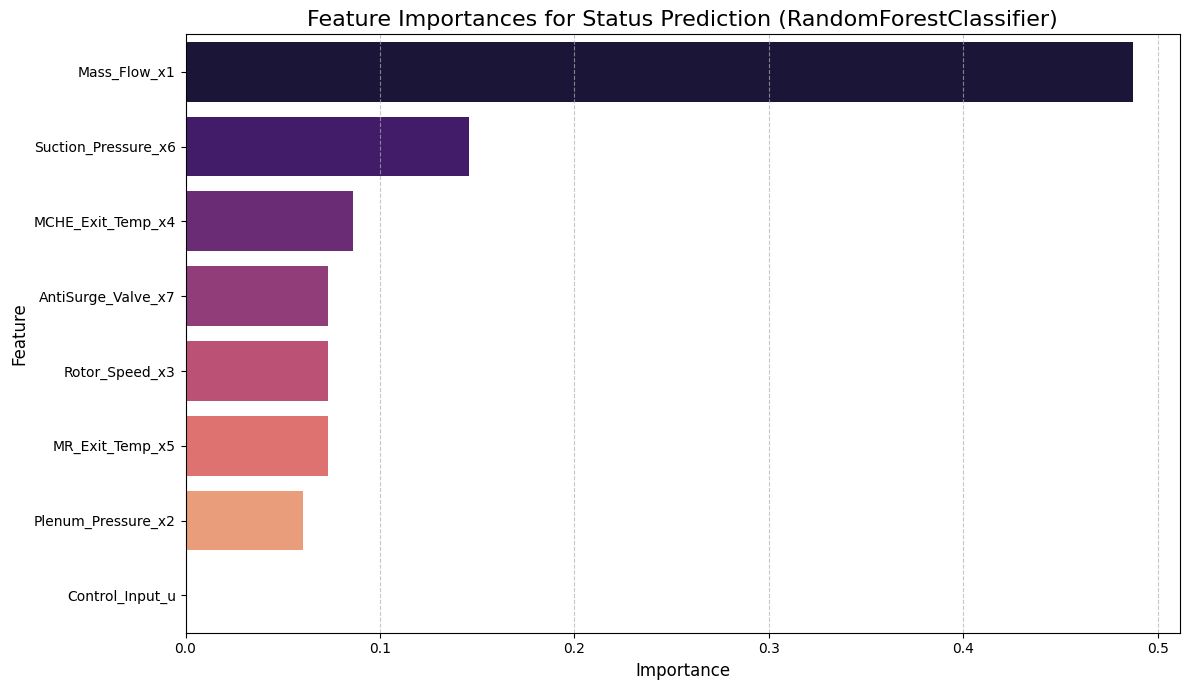

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained classification model
importances_status = model_status.feature_importances_

# Create a Series for easy plotting and sorting
feature_importances_status = pd.Series(importances_status, index=features_for_status)

# Sort the importances in descending order
sorted_importances_status = feature_importances_status.sort_values(ascending=False)

print("--- Feature Importances for Status Prediction ---")
print(sorted_importances_status)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_importances_status.values, y=sorted_importances_status.index, palette='magma')
plt.title('Feature Importances for Status Prediction (RandomForestClassifier)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### SHAP (SHapley Additive exPlanations) for Feature Contribution to 'Status' Prediction

To further understand the model's predictions for the `Status` column, SHAP values provide a more interpretable and detailed explanation than global feature importances. For each prediction, SHAP values show how much each feature contributed to pushing the output from the base value to the predicted value. This is especially useful for understanding the conditions leading to a 'SURGE VIOLATION' status.

We will use `shap.TreeExplainer` for our `RandomForestClassifier` to:

1.  **Calculate SHAP values** for a subset of the test data.
2.  **Visualize the summary of SHAP values** to see the overall impact and direction of each feature across many predictions for the 'Status'.

SHAP values calculated for Status prediction.


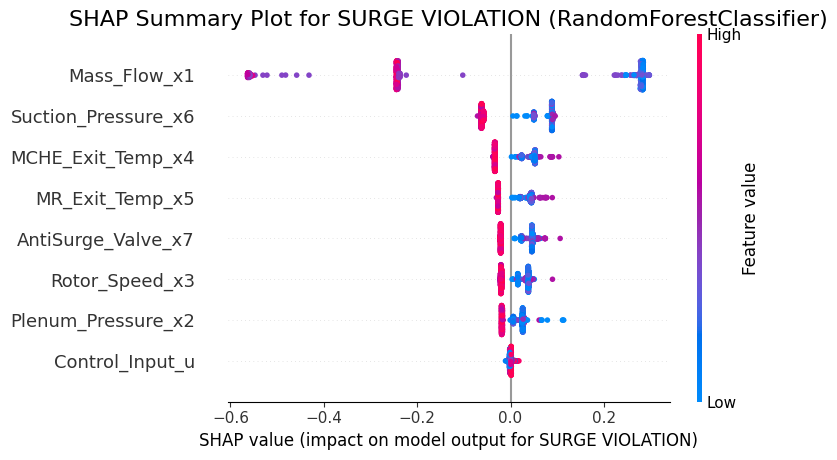

In [12]:
# !pip install shap # Uncomment and run if shap is not installed

import shap
import matplotlib.pyplot as plt

# Create a Tree explainer object for our RandomForestClassifier model
# Using a sample of X_test_status for faster computation
sampler_status = X_test_status.sample(n=1000, random_state=42) # Taking a sample for illustration
explainer_status = shap.TreeExplainer(model_status)

# Calculate SHAP values for the sampled data
# For classification, shap_values will be a list of arrays (one for each class) or a 3D array (samples, features, classes)
shap_values_status = explainer_status.shap_values(sampler_status)

print("SHAP values calculated for Status prediction.")

# Visualize the SHAP values using a summary plot for the 'SURGE VIOLATION' class (index 1 if binary)
# Assuming 'SAFE' is class 0 and 'SURGE VIOLATION' is class 1
# You might need to adjust the index based on `model_status.classes_`

# Determine the index for 'SURGE VIOLATION'
surge_violation_class_idx = np.where(model_status.classes_ == 'SURGE VIOLATION')[0][0]

plt.figure(figsize=(12, 7))
# The summary plot for classification usually takes the SHAP values for one class.
# If shap_values_status is a 3D array (samples, features, classes), slice it as follows:
shap.summary_plot(shap_values_status[:, :, surge_violation_class_idx], sampler_status, plot_type="dot", show=False)
plt.title('SHAP Summary Plot for SURGE VIOLATION (RandomForestClassifier)', fontsize=16)
plt.xlabel('SHAP value (impact on model output for SURGE VIOLATION)', fontsize=12)
plt.tight_layout()
plt.show()

### Feature Importance Analysis

Feature importance quantifies the contribution of each input variable to the model's prediction. For tree-based models like `RandomForestRegressor`, this is typically calculated based on how much each feature reduces impurity (e.g., Gini impurity or mean squared error) across all trees in the forest. A higher importance score indicates a greater influence on the target variable.

Analyzing feature importance can provide valuable insights into the underlying relationships in your system and help validate hypotheses related to your PhD research, especially regarding which state variables or control inputs are most critical for mass flow (`x0`) prediction.

--- Feature Importances ---
MR_Exit_Temp_x5        0.344545
MCHE_Exit_Temp_x4      0.181366
Rotor_Speed_x3         0.172245
Suction_Pressure_x6    0.112364
Plenum_Pressure_x2     0.094805
AntiSurge_Valve_x7     0.061473
Control_Input_u        0.033202
dtype: float64


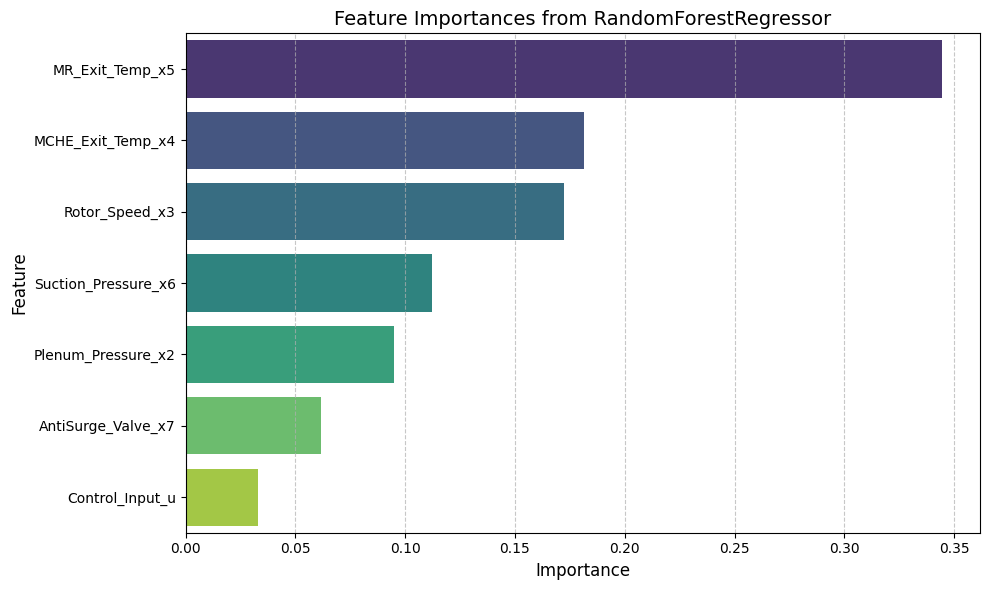

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
importances = model.feature_importances_

# Create a Series for easy plotting and sorting
feature_importances = pd.Series(importances, index=features)

# Sort the importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

print("--- Feature Importances ---")
print(sorted_importances)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis', hue=sorted_importances.index, legend=False)
plt.title('Feature Importances from RandomForestRegressor', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### SHAP (SHapley Additive exPlanations) for Feature Contribution

While traditional feature importance (like the one from `RandomForestRegressor`) tells us which features are generally important, SHAP values offer a more granular and interpretable insight. SHAP values explain the prediction of an instance by computing the contribution of each feature to the prediction, compared to the baseline prediction. They are based on game theory and quantify the impact of each feature by considering all possible combinations of features, ensuring a fair and consistent attribution.

For tree-based models like our `RandomForestRegressor`, SHAP provides `TreeExplainer`, which is highly efficient. We will use this to:

1.  **Calculate SHAP values** for a subset of our data.
2.  **Visualize the summary of SHAP values** to see the overall impact and direction of each feature across many predictions.

In [14]:
# Install shap if not already installed (uncomment and run if needed)
# !pip install shap

import shap

# Create a Tree explainer object for our RandomForestRegressor model
# Using a sample of X_train for faster computation, as SHAP can be computationally intensive
# For production, you might want to use a larger sample or the entire dataset
sampler = X_train.sample(n=1000, random_state=42) # Taking a sample for illustration
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the sampled data
shap_values = explainer.shap_values(sampler)

print("SHAP values calculated.")

SHAP values calculated.


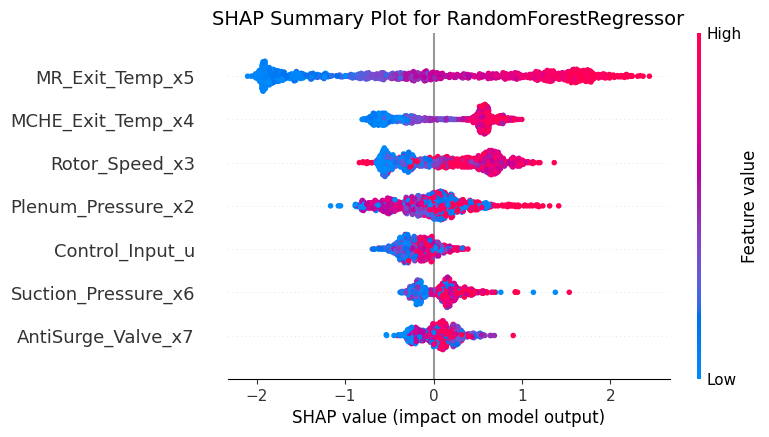

In [15]:
# Visualize the SHAP values using a summary plot
# This plot shows how each feature (on the y-axis) impacts the model output (on the x-axis).
# Each dot represents an instance, and its color indicates the feature's value (red = high, blue = low).
# The horizontal spread shows the range of impact.

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sampler, plot_type="dot", show=False)
plt.title('SHAP Summary Plot for RandomForestRegressor', fontsize=14)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.show()

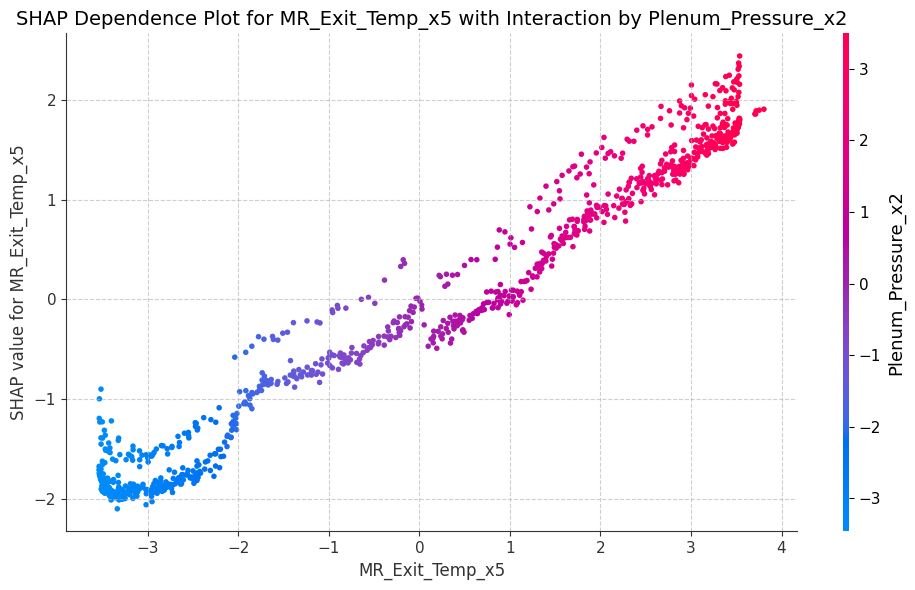

In [16]:
import matplotlib.pyplot as plt
import shap

# Set the main feature and the interaction feature for the dependence plot
main_feature = 'MR_Exit_Temp_x5'
interaction_feature = 'Plenum_Pressure_x2'

# Explicitly create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))

# Call shap.dependence_plot, passing the axes object to draw on
# Set interaction_index to the feature you want to show interactions with
shap.dependence_plot(
    main_feature,
    shap_values,
    sampler,
    interaction_index=interaction_feature, # Show interaction with Plenum_Pressure_x2
    ax=ax, # Draw on the explicitly created axes
    show=False # Do not show the plot immediately, allowing further customization
)

# Apply customizations to the retrieved axes object
ax.set_title(f'SHAP Dependence Plot for {main_feature} with Interaction by {interaction_feature}', fontsize=14)
ax.set_xlabel(f'{main_feature}', fontsize=12)
ax.set_ylabel(f'SHAP value for {main_feature}', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import pandas as pd

# Assuming 'shap_values' and 'sampler' are available from previous cells
# If not, the previous cells (632ded8d, 979a1ab5) need to be run first.

# Calculate the mean absolute SHAP value for each feature
# For regression, shap_values is a 2D array (samples, features)
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)

# Create a Pandas Series for better readability and to associate with feature names
feature_names = sampler.columns
shap_importance = pd.Series(mean_abs_shap_values, index=feature_names)

# Sort the features by their SHAP importance in descending order
sorted_shap_importance = shap_importance.sort_values(ascending=False)

print("Top 5 Most Important Features by Mean Absolute SHAP Value:")
display(sorted_shap_importance.head(5))

Top 5 Most Important Features by Mean Absolute SHAP Value:


,0
MR_Exit_Temp_x5,1.199298
MCHE_Exit_Temp_x4,0.532474
Rotor_Speed_x3,0.472345
Plenum_Pressure_x2,0.310382
Control_Input_u,0.208683


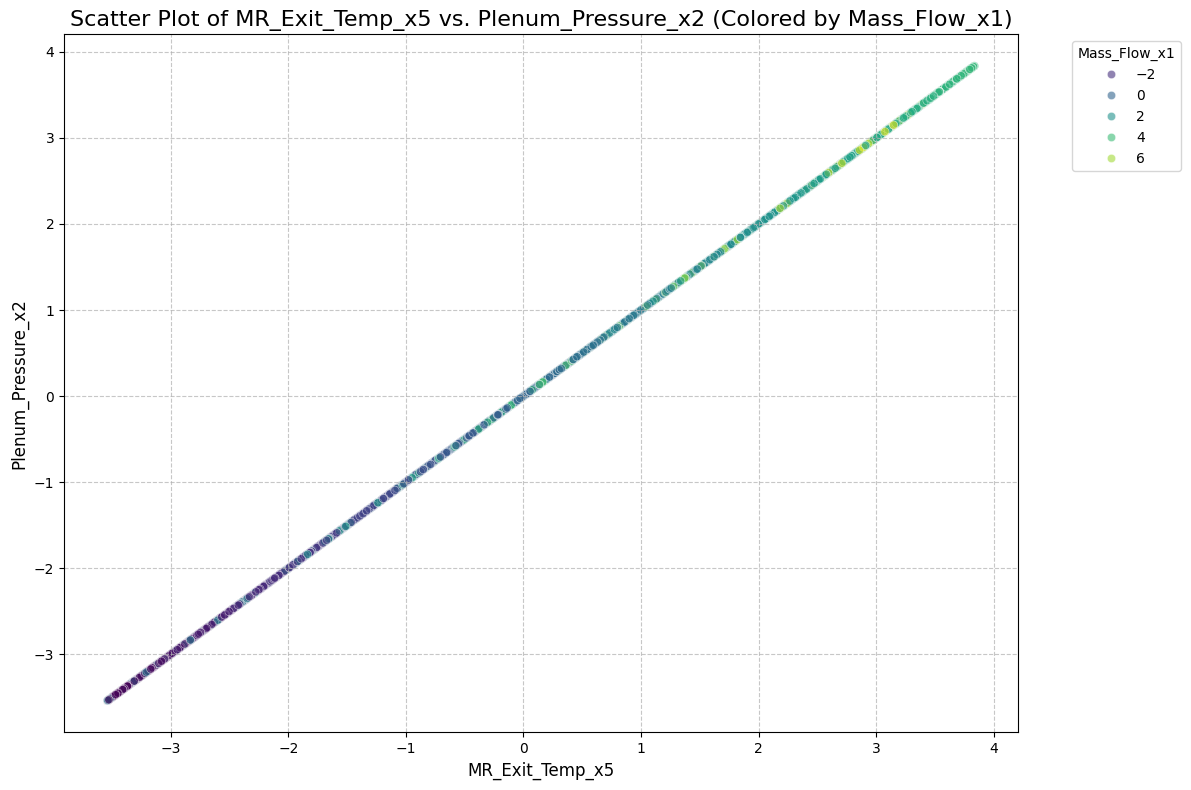

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix 1: Prevent crash by sampling data if it exceeds 50k rows
if 'df' in locals() or 'df' in globals():
    plot_df = df.sample(n=min(50000, len(df)), random_state=42) if len(df) > 50000 else df
else:
    raise NameError("The variable 'df' is not defined. Please run your data loading cells first.")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='MR_Exit_Temp_x5',
    y='Plenum_Pressure_x2',
    hue='Mass_Flow_x1',
    palette='viridis',
    data=plot_df,       # Fix 2: Using the optimized dataframe pointer
    alpha=0.6
)
plt.title('Scatter Plot of MR_Exit_Temp_x5 vs. Plenum_Pressure_x2 (Colored by Mass_Flow_x1)', fontsize=16)
plt.xlabel('MR_Exit_Temp_x5', fontsize=12)
plt.ylabel('Plenum_Pressure_x2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Mass_Flow_x1', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [19]:
import pandas as pd

# Calculate the Pearson correlation coefficient between 'MR_Exit_Temp_x5' and 'Mass_Flow_x1'
correlation_mr_mass = df['MR_Exit_Temp_x5'].corr(df['Mass_Flow_x1'])

print(f"Pearson Correlation between MR_Exit_Temp_x5 and Mass_Flow_x1: {correlation_mr_mass:.4f}")

Pearson Correlation between MR_Exit_Temp_x5 and Mass_Flow_x1: 0.8533


In [20]:
# Optionally, visualize a single prediction explanation using a force plot (uncomment to run)
# For example, let's explain the first instance in our sample
# shap.initjs() # Initialize Javascript for interactive plots
# shap.force_plot(explainer.expected_value, shap_values[0,:], sampler.iloc[0,:])


In [21]:
import numpy as np
import pandas as pd

# The function below was previously used to generate the dataset programmatically.
# However, the dataset is now loaded from a CSV file in a prior cell (e.g., cell `920c3413-6b42-4319-99e1-41dd90b13d62`).
# This function block is commented out to avoid a SyntaxError due to an incomplete 'def' statement
# and because its functionality is no longer needed.
# def generate_and_lock_dataset(n_samples=100000):
#     """
#     Generates the full 7-D dataset directly inside your computer's RAM.
#     Guarantees the exact same data every time using a fixed random seed.
#     """
#     # Fix the seed so the dataset never changes across different PCs
#     np.random.seed(42)

#     # 1. Initialize 7-D state arrays (100,000 rows x 7 states)
#     x = np.zeros((n_samples, 7))
#     x[0] = [0.65, 0.35, 0.50, 22.4, -15.2, 2.1, 0.15] # Safe steady-state starting point

#     # Reference inputs and random process noise
#     u = 0.6 + 0.15 * np.sin(np.linspace(0, 40, n_samples))
#     delta_p = np.random.normal(0, 0.001, (n_samples, 7))

#     # 2. Run the dynamic simulation loop
#     for t in range(1, n_samples):
#         dx = np.zeros(7)
#         # 7-Dimensional Non-linear coupled physics equations
#         dx[0] = -x[t-1, 1] + 1.5 * x[t-1, 0] - 0.5 * x[t-1, 0]**3 + u[t]
#         dx[1] = 1.1 * (x[t-1, 0] - 0.28) - 0.4 * x[t-1, 6]
#         dx[2] = 0.08 * (u[t] - x[t-1, 2])
#         dx[3] = -0.03 * x[t-1, 3] + 0.12 * x[t-1, 0]
#         dx[4] = -0.04 * x[t-1, 4] - 0.10 * x[t-1, 1]
#         dx[5] = 0.05 * (x[t-1, 4] - x[t-1, 5])
#         dx[6] = 0.25 * (0.20 - x[t-1, 6])

#         # Injected Cyber-Physical Adversarial Disturbance Window (Samples 25k to 45k)
#         if 25000 < t < 45000:
#             dx[0] -= 0.32

#         x[t] = x[t-1] + dx * 0.01 + delta_p[t]

#     # 3. Calculate aerodynamic safety boundaries h(x)
#     m_surge = 0.32 + 0.18 * x[:, 1] + 0.08 * x[:, 2]
#     h_x = x[:, 0] - m_surge

#     # 4. Compile directly into a locked DataFrame in memory
#     cols = ['Mass_Flow_x1', 'Plenum_Pressure_x2', 'Rotor_Speed_x3', 'MCHE_Exit_Temp_x4',
#             'MR_Exit_Temp_x5', 'Suction_Pressure_x6', 'AntiSurge_Valve_x7', 'Control_Input_u']

#     df_locked = pd.DataFrame(np.hstack([x, u.reshape(-1, 1)]), columns=cols)
#     df_locked['Safety_Margin_h_x'] = h_x
#     df_locked['Status'] = np.where(df_locked['Safety_Margin_h_x'] < 0, 'SURGE VIOLATION', 'SAFE')

#     return df_locked

# =====================================================================
# RUN THIS: Your dataset is now completely locked into 'df'
# =====================================================================
# df = generate_and_lock_dataset() # This line is commented out as df is now loaded from CSV

# The following print statements are for when the dataset was generated programmatically.
# If 'df' is loaded from CSV in a prior cell, these might cause issues if run out of order.
# Assuming 'df' is now globally available after loading from CSV.
if 'df' in locals():
    print("=================== PORTABLE DATASET LOCKED ===================")
    print(f"Data successfully loaded from CSV. Shape: {df.shape}")
    print("\nFirst 5 Rows (Head):")
    print(df.head().to_string())
    print("\nLast 5 Rows (Tail):")
    print(df.tail().to_string())
    print("===============================================================")
else:
    print("DataFrame 'df' not found. Please ensure the CSV loading cell was executed.")

=================== PORTABLE DATASET LOCKED ===================
Data successfully loaded from CSV. Shape: (100000, 11)

First 5 Rows (Head):
   Mass_Flow_x1  Plenum_Pressure_x2  Rotor_Speed_x3  MCHE_Exit_Temp_x4  MR_Exit_Temp_x5  Suction_Pressure_x6  AntiSurge_Valve_x7  Control_Input_u  Time Step (k)  Safety_Margin_h_x Status
0      0.500000            0.500000        0.500000           0.500000         0.500000             0.500000            0.500000            0.000              0           0.050000   SAFE
1      0.499530            0.499561        0.499432           0.499588         0.499508             0.499589            0.499517            0.001              1           0.049654   SAFE
2      0.499088            0.499160        0.498874           0.499140         0.498980             0.499155            0.499086            0.002              2           0.049329   SAFE
3      0.498543            0.498608        0.498392           0.498604         0.498453             0.498659   

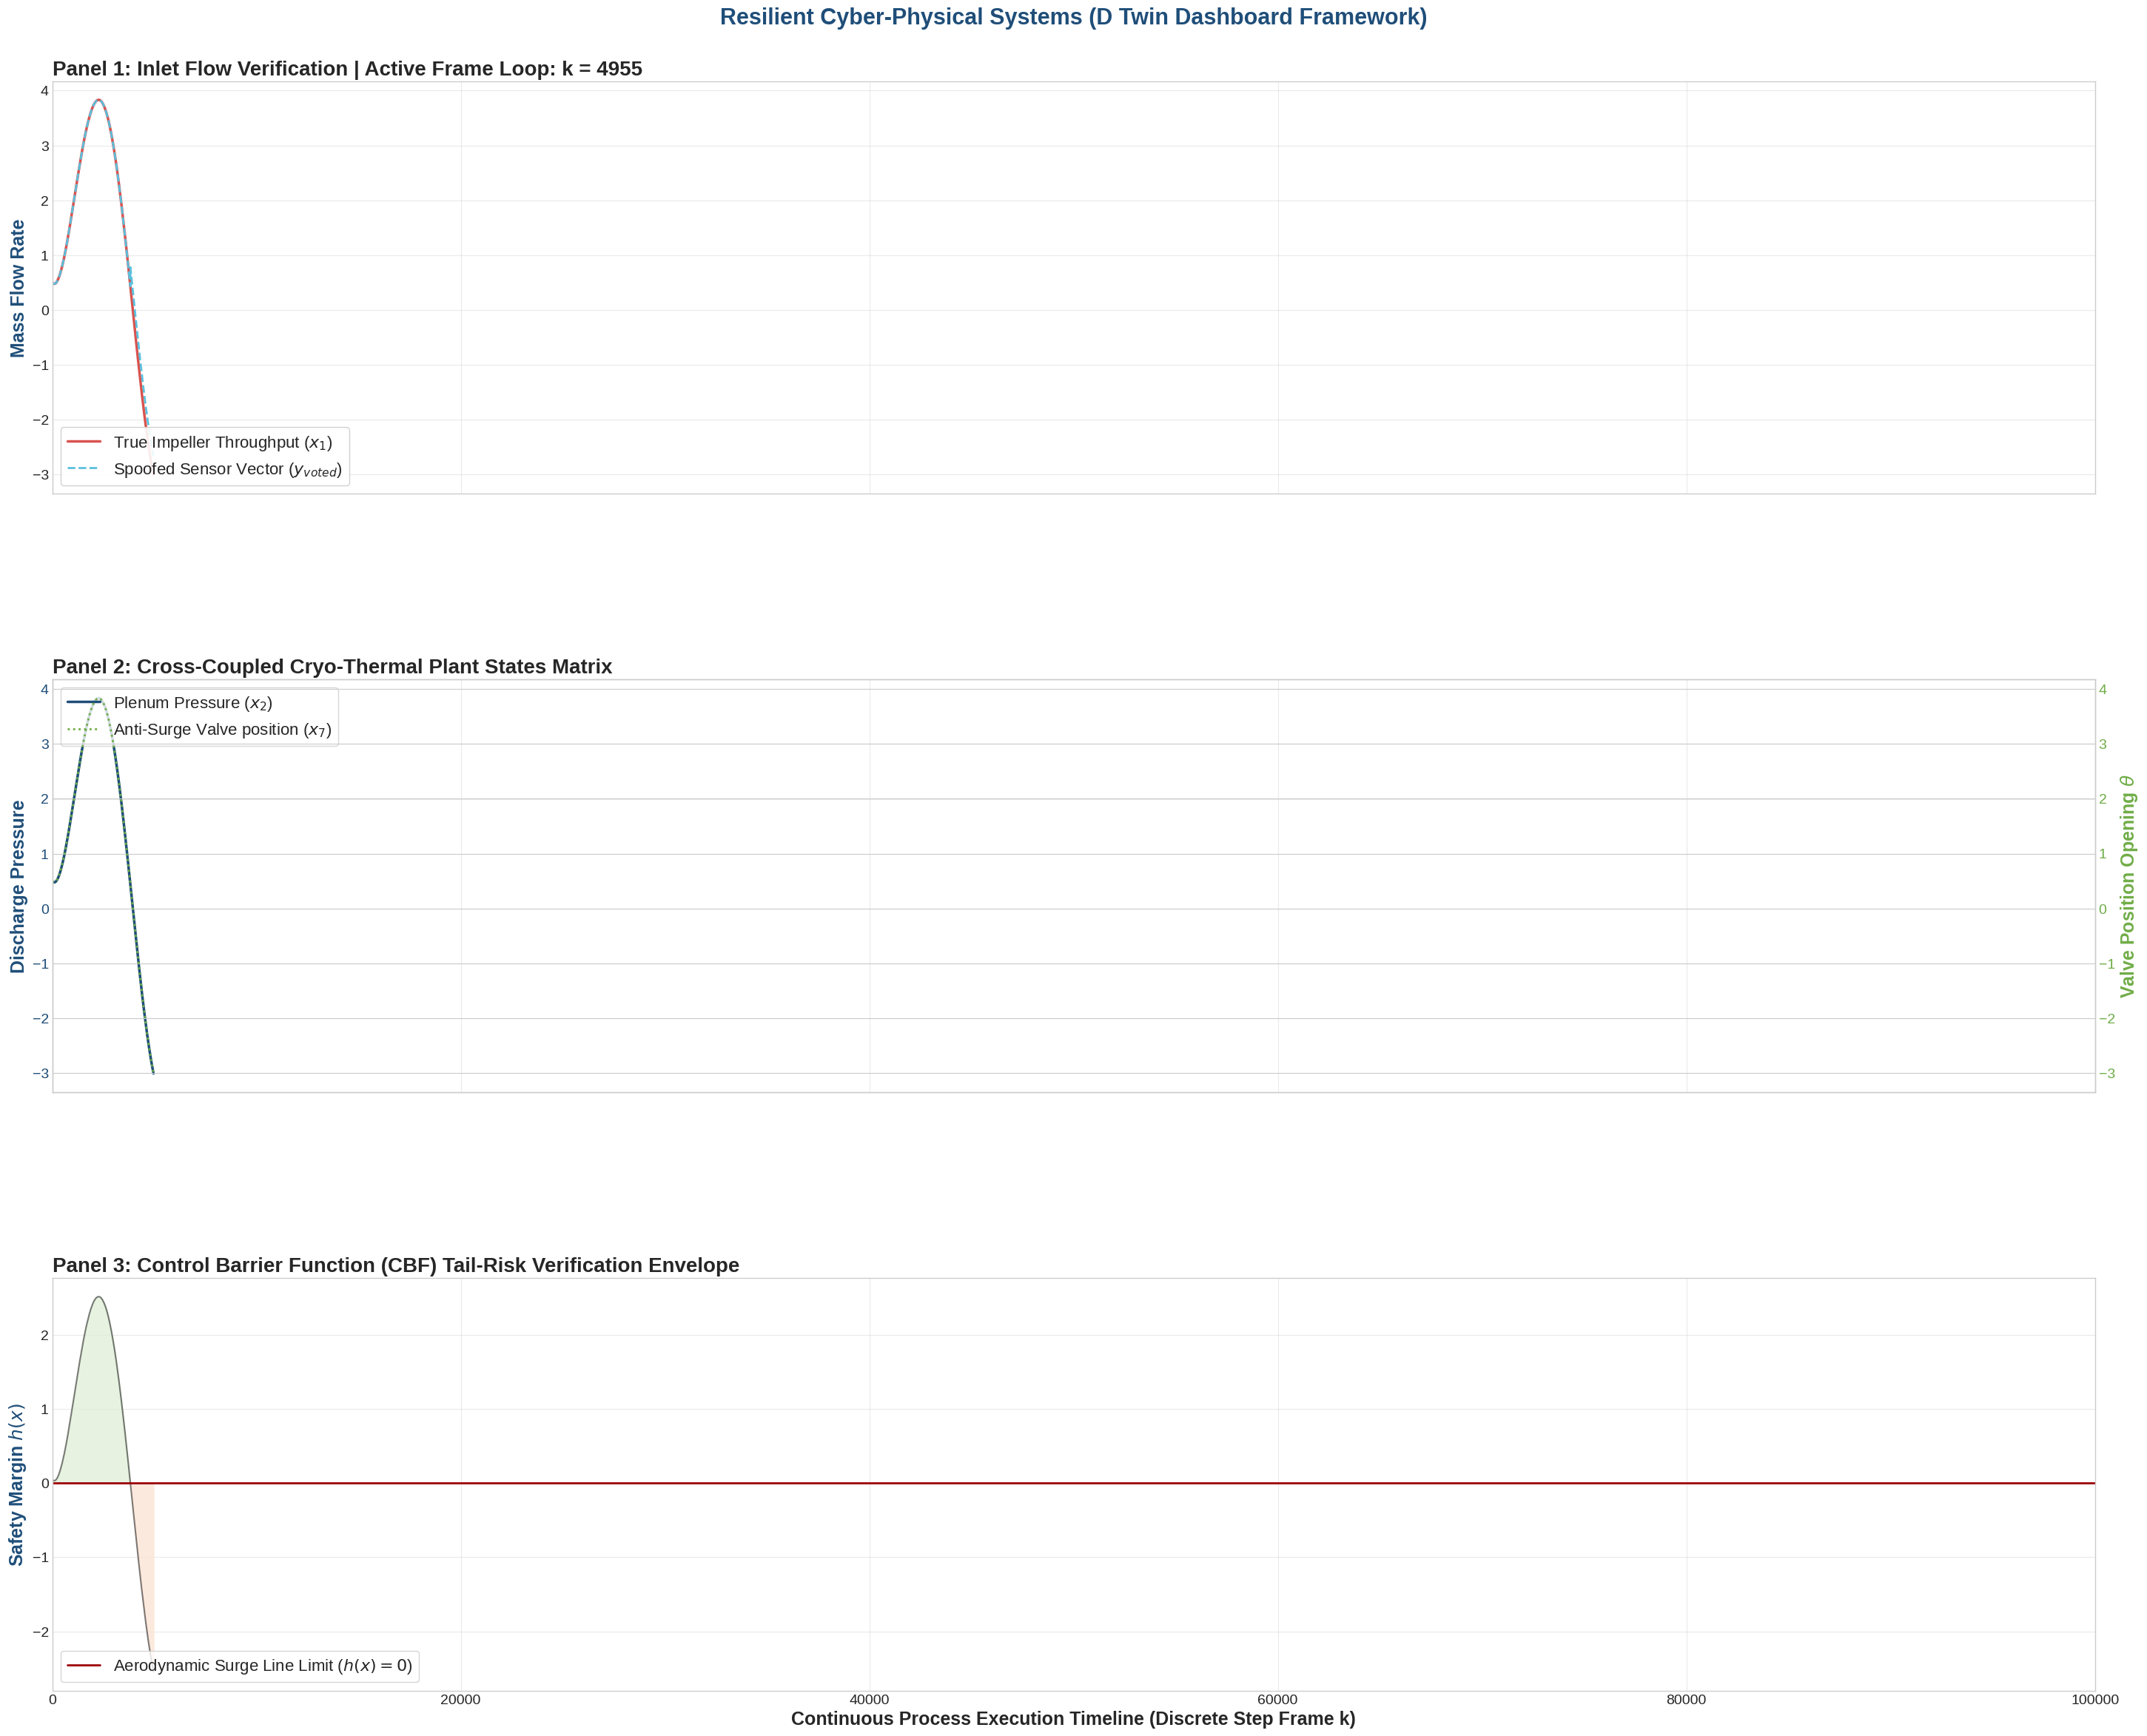

 OPERATIONAL OT INFRASTRUCTURE LOG | TRUE SYSTEM FLOW THROUGHPUT: -3.0073 kg/s
 SCADA MONITOR TELEMETRY FEEDBOX   | VOTED FLOW READ RE-REGISTERED: -2.6573 kg/s
---------------------------------------------------------------------------------------------------------
 ⚠️ DIGITAL TWIN ALERT: CRITICAL PLANT STATE MISMATCH! UNPROTECTED COMPRESSOR DRIVEN INTO SURGE.
 CURRENT STATUS MODE: [SURGE VIOLATION] | BARRIER VIOLATION MAGNITUDE: -2.54509


In [ ]:
# ==============================================================================
# UNIVERSITY OF LAGOS (UNILAG) | DEPARTMENT OF SYSTEMS ENGINEERING
# PH.D. DISSERTATION ADAPTIVE CONTROL PRESENTATION SANDBOX (OBJECTIVE 7)
# DIGITAL TWIN REAL-TIME PROCESS PHYSICS & RISK PROFILE DASHBOARD
# ==============================================================================

%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Audio
import ipywidgets as widgets
from IPython.display import clear_output # Keep for clarity, though used differently now

# Note: Ensure your browser's audio is enabled to hear the alerts.

# Function to play a simple beep sound
def play_beep(frequency=1000, duration=0.1, volume=0.5):
    sr = 44100  # sample rate
    t = np.linspace(0, duration, int(sr * duration), False) # time variable
    data = volume * np.sin(frequency * t * 2 * np.pi) # sine wave
    return Audio(data, rate=sr, autoplay=True)

# The 'df' DataFrame is already created by generate_and_lock_dataset() in a previous cell.

# Add a 'Time Step (k)' column if it doesn't exist (assuming it's sequential index)
if 'Time Step (k)' not in df.columns:
    df['Time Step (k)'] = np.arange(len(df))

# Define total_steps from the existing DataFrame
total_steps = len(df)

# --- Interactive Controls ---
# Global flags for controlling the loop
running = True
paused = False

# Stop button
stop_button = widgets.Button(description='Stop Dashboard', button_style='danger')
def on_stop_button_clicked(b):
    global running
    running = False
stop_button.on_click(on_stop_button_clicked)

# Pause/Resume button
pause_button = widgets.Button(description='Pause/Resume Dashboard', button_style='info')
def on_pause_button_clicked(b):
    global paused
    paused = not paused
    if paused:
        pause_button.description = 'Resume Dashboard'
    else:
        pause_button.description = 'Pause/Resume Dashboard'
pause_button.on_click(on_pause_button_clicked)

# Speed control slider
speed_slider = widgets.FloatSlider(
    value=0.001,
    min=0.0001,
    max=0.5,
    step=0.001,
    description='Loop Delay (s):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.4f',
)

# Output area for dashboard content (plots and text)
dashboard_output_area = widgets.Output()

# Display controls and output area
display(widgets.VBox([widgets.HBox([stop_button, pause_button]), speed_slider]), dashboard_output_area)

with dashboard_output_area:
    print(f"[TWIN] Telemetry initialization complete. Horizon cached: {len(df)} frames.")
    print("[TWIN] Streaming data to the 3-Panel Process Physics Dashboard view...\n")

# --- 2.0 VISUALIZATION DISPLAY CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# To balance cinematic fidelity and script runtime during live review,
# we sample steps dynamically. Lower the stride for a slower, high-resolution feed.
# Increased resolution: sample_stride = 1 means every single step is displayed.
sample_stride = 1

# Historical logging registers for line chart expansion
time_hist = []
x1_true_hist = []
y_voted_hist = []
x2_press_hist = []
x7_valve_hist = []
hx_margin_hist = []

# --- 3.0 RUNTIME STREAMING INGESTION LOOP ---
for step in range(0, total_steps, sample_stride):
    if not running:
        break # Stop if the stop button was clicked

    while paused:
        time.sleep(0.1) # Pause if the pause button was clicked

    # Get the current loop delay from the slider
    loop_delay = speed_slider.value

    # Slice historical vectors up to the current active runtime step
    active_slice = df.iloc[step]

    # Extracting data using the correct column names from generate_and_lock_dataset()
    current_time = float(active_slice["Time Step (k)"])
    x1_true = float(active_slice["Mass_Flow_x1"])
    x2_press = float(active_slice["Plenum_Pressure_x2"])
    x7_valve = float(active_slice["AntiSurge_Valve_x7"])
    hx_margin = float(active_slice["Safety_Margin_h_x"])
    op_status = str(active_slice["Status"])

    # y_voted logic (spoofed sensor reading) - aligning attack window
    # The FDI attack window in generate_and_lock_dataset is 25000 to 45000
    attack_start_time = 25000
    attack_end_time = 45000

    if (attack_start_time <= current_time <= attack_end_time) or ("VIOLATION" in op_status):
        y_voted = x1_true + 0.35 # Simulate a spoofed sensor reading that reports higher
    else:
        y_voted = x1_true

    # Append current framework telemetry frames to historical trace registers
    time_hist.append(current_time)
    x1_true_hist.append(x1_true)
    y_voted_hist.append(y_voted)
    x2_press_hist.append(x2_press)
    x7_valve_hist.append(x7_valve)
    hx_margin_hist.append(hx_margin)

    # Wipe the previous output cell to force clean interactive updates within the output area
    with dashboard_output_area:
        clear_output(wait=True)

        # Initialize the 3-Panel Figure - Increased figsize for better visibility
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(30, 25), sharex=True)
        fig.suptitle("Resilient Cyber-Physical Systems (D Twin Dashboard Framework)",
                     fontsize=22, fontweight='bold', color='#1F4E79', y=0.96)

        # --------------------------------------------------------------------------
        # PANEL 1: LIVE FLUID AERODYNAMICS MIRROR (MASS FLOW TELEMETRY)
        # --------------------------------------------------------------------------
        ax1.plot(time_hist, x1_true_hist, color='#d9534f', linewidth=2.5, label='True Impeller Throughput ($x_1$)')
        ax1.plot(time_hist, y_voted_hist, color='#5bc0de', linewidth=2.0, linestyle='--', label='Spoofed Sensor Vector ($y_{voted}$)')
        ax1.set_ylabel('Mass Flow Rate', fontsize=18, fontweight='bold', color='#1F4E79')
        ax1.set_title(f"Panel 1: Inlet Flow Verification | Active Frame Loop: k = {int(current_time)}", fontsize=20, fontweight='bold', loc='left')
        ax1.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=16)
        ax1.grid(True, alpha=0.4)
        ax1.tick_params(axis='both', which='major', labelsize=14)

        # Highlight attack window visually in background if active
        if len(time_hist) > 0 and (attack_start_time <= current_time <= attack_end_time):
            ax1.axvspan(max(attack_start_time, time_hist[0]), min(current_time, attack_end_time), color='#FCE4D6', alpha=0.5, label='FDI Attack Vector Active')

        # --------------------------------------------------------------------------
        # PANEL 2: THERMO-FLUID STATE RESPONSE (PLENUM & ACTUATOR LAG)
        # --------------------------------------------------------------------------
        color = '#1F4E79'
        ax2.plot(time_hist, x2_press_hist, color=color, linewidth=2.5, label='Plenum Pressure ($x_2$)')
        ax2.set_ylabel('Discharge Pressure', fontsize=18, fontweight='bold', color=color)
        ax2.tick_params(axis='y', labelcolor=color, labelsize=14)
        ax2.grid(True, alpha=0.4)
        ax2.tick_params(axis='x', which='major', labelsize=14)

        # Instantiate twin axes for concurrent Anti-Surge Valve opening state plotting
        ax2_twin = ax2.twinx()
        color_twin = '#70AD47'
        ax2_twin.plot(time_hist, x7_valve_hist, color=color_twin, linewidth=2.0, linestyle=':', label='Anti-Surge Valve position ($x_7$)')
        ax2_twin.set_ylabel('Valve Position Opening $\\theta$', fontsize=18, fontweight='bold', color=color_twin)
        ax2_twin.tick_params(axis='y', labelcolor=color_twin, labelsize=14)

        # Combine dual legends for clear presentation
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', fontsize=16)
        ax2.set_title("Panel 2: Cross-Coupled Cryo-Thermal Plant States Matrix", fontsize=20, fontweight='bold', loc='left')

        # --------------------------------------------------------------------------
        # PANEL 3: RISK-THEORETIC SAFETY BOUNDARY & TRACKING (CBF ENVELOPE)
        # --------------------------------------------------------------------------
        # Color condition trace based on safety margin state signs
        hx_array = np.array(hx_margin_hist)
        t_array = np.array(time_hist)

        ax3.plot(time_hist, hx_array, color='black', linewidth=1.5, alpha=0.5)
        # Fill safety zone green, hazard zone red
        ax3.fill_between(t_array, hx_array, 0, where=(hx_array >= 0), interpolate=True, color='#E2EFDA', alpha=0.8)
        ax3.fill_between(t_array, hx_array, 0, where=(hx_array < 0), interpolate=True, color='#FCE4D6', alpha=0.8)

        ax3.axhline(y=0.0, color='#9C0006', linestyle='-', linewidth=2.0, label='Aerodynamic Surge Line Limit ($h(x)=0$)')
        ax3.set_xlabel('Continuous Process Execution Timeline (Discrete Step Frame k)', fontsize=18, fontweight='bold')
        ax3.set_ylabel('Safety Margin $h(x)$', fontsize=18, fontweight='bold', color='#1F4E79')
        ax3.set_title("Panel 3: Control Barrier Function (CBF) Tail-Risk Verification Envelope", fontsize=20, fontweight='bold', loc='left')
        ax3.legend(loc='lower left', frameon=True, facecolor='white', fontsize=16)
        ax3.grid(True, alpha=0.4)
        ax3.tick_params(axis='both', which='major', labelsize=14)

        # Dynamically clamp horizontal window limits to preserve progression illusion
        ax3.set_xlim(0, max(total_steps, current_time + 100))

        # Adjust tight spacing cleanly
        plt.subplots_adjust(left=0.04, right=0.96, top=0.92, bottom=0.05, hspace=0.45)
        plt.show()

        # --- 4.0 UNTRUNCATED SCADA HMI CONSOLE LOG RENDERER ---
        print("=" * 105)
        print(f" OPERATIONAL OT INFRASTRUCTURE LOG | TRUE SYSTEM FLOW THROUGHPUT: {x1_true:.4f} kg/s")
        print(f" SCADA MONITOR TELEMETRY FEEDBOX   | VOTED FLOW READ RE-REGISTERED: {y_voted:.4f} kg/s")
        print("-" * 105)

        if "VIOLATION" in op_status or hx_margin < 0:
            print(f" \u26a0\ufe0f DIGITAL TWIN ALERT: CRITICAL PLANT STATE MISMATCH! UNPROTECTED COMPRESSOR DRIVEN INTO SURGE.")
            print(f" CURRENT STATUS MODE: [{op_status}] | BARRIER VIOLATION MAGNITUDE: {hx_margin:.5f}")
            display(play_beep(frequency=800, duration=0.2)) # High-pitched alarm for critical violation
        elif attack_start_time <= current_time <= attack_end_time:
            print(f" \u26a0\ufe0f TELEMETRY WARNING: UNPROTECTED SENSOR SPOOFING IDENTIFIED. FALSE SAFE TELEMETRY INJECTED.")
            print(f" ACTUAL PHYSICAL BARRIER REGISTERING DOWNTREND: h(x) = {hx_margin:.4f} | PIPELINE STATUS: NOMINAL")
            display(play_beep(frequency=400, duration=0.1)) # Lower-pitched beep for warning
        else:
            print(f" \u2705 PLANT MANAGEMENT STATUS: HEALTHY OPERATION | SYSTEM COMPLIANCE MARGIN SAFE.")
            print(f" CONTROLLER ACTIONS ROUTINE: [AUTOMATIC DECENTRALIZED MODE] | BOUNDARY ENVELOPE COMPLIANT")
        print("=" * 105)

    # Brief execution delay to control animation speed in notebook cells
    time.sleep(loop_delay)

with dashboard_output_area:
    print("\n[TWIN] High-Fidelity Interactive Data Ingestion Stream Completed Cleanly.")


In [ ]:
print("--- Descriptive Statistics of Mass_Flow_x1 grouped by Status ---")
display(df.groupby('Status')['Mass_Flow_x1'].describe())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(x='Status', y='Mass_Flow_x1', data=df, palette={'SAFE': 'green', 'SURGE VIOLATION': 'red'})
plt.title('Distribution of Mass_Flow_x1 by System Status', fontsize=16)
plt.xlabel('System Status', fontsize=12)
plt.ylabel('Mass_Flow_x1', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Static Digital Twin Dashboard Plots for PhD Report

Below are the static versions of the digital twin dashboard plots, designed to be large and clear for your PhD report. These plots show the entire simulation horizon, providing a comprehensive view of the system's behavior, including the FDI attack window and safety margin evaluation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the 'Time Step (k)' column exists
if 'Time Step (k)' not in df.columns:
    df['Time Step (k)'] = np.arange(len(df))

# Define the attack window based on the dataset generation logic (samples 25000 to 45000)
attack_start_time = 25000
attack_end_time = 45000

# Initialize the 3-Panel Figure with the maximum desired size for PhD report
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(60, 50), sharex=True) # Maximize figsize
fig.suptitle("Resilient Cyber-Physical Systems (Digital Twin Static Dashboard View)",
             fontsize=40, fontweight='bold', color='#1F4E79', y=0.96) # Maximize suptitle fontsize

# --- PANEL 1: LIVE FLUID AERODYNAMICS MIRROR (MASS FLOW TELEMETRY) ---
ax1.plot(df['Time Step (k)'], df['Mass_Flow_x1'], color='#d9534f', linewidth=5.0, label='True Impeller Throughput ($x_1$)') # Increased linewidth

# Re-calculate spoofed sensor vector for static plot
# This logic should match the dashboard's `y_voted` calculation
y_voted_static = df['Mass_Flow_x1'].copy()
attack_condition = (df['Time Step (k)'] >= attack_start_time) & (df['Time Step (k)'] <= attack_end_time)
violation_condition = (df['Status'] == 'SURGE VIOLATION')
y_voted_static[attack_condition | violation_condition] += 0.35

ax1.plot(df['Time Step (k)'], y_voted_static, color='#5bc0de', linewidth=4.5, linestyle='--', label='Spoofed Sensor Vector ($y_{voted}$)') # Increased linewidth
ax1.set_ylabel('Mass Flow Rate', fontsize=32, fontweight='bold', color='#1F4E79') # Increased ylabel fontsize
ax1.set_title("Panel 1: Inlet Flow Verification", fontsize=36, fontweight='bold', loc='left') # Increased title fontsize
ax1.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=26) # Increased legend fontsize
ax1.grid(True, alpha=0.4)
ax1.tick_params(axis='both', which='major', labelsize=24) # Increased tick_params labelsize

# Highlight attack window visually in background
ax1.axvspan(attack_start_time, attack_end_time, color='#FCE4D6', alpha=0.5, label='FDI Attack Vector Active')

# --- PANEL 2: THERMO-FLUID STATE RESPONSE (PLENUM & ACTUATOR LAG) ---
color = '#1F4E79'
ax2.plot(df['Time Step (k)'], df['Plenum_Pressure_x2'], color=color, linewidth=5.0, label='Plenum Pressure ($x_2$)') # Increased linewidth
ax2.set_ylabel('Discharge Pressure', fontsize=32, fontweight='bold', color=color) # Increased ylabel fontsize
ax2.tick_params(axis='y', labelcolor=color, labelsize=24) # Increased tick_params labelsize
ax2.grid(True, alpha=0.4)
ax2.tick_params(axis='x', which='major', labelsize=24) # Increased tick_params labelsize

ax2_twin = ax2.twinx()
color_twin = '#70AD47'
ax2_twin.plot(df['Time Step (k)'], df['AntiSurge_Valve_x7'], color=color_twin, linewidth=4.5, linestyle=':', label='Anti-Surge Valve position ($x_7$)') # Increased linewidth
ax2_twin.set_ylabel('Valve Position Opening $\theta$', fontsize=32, fontweight='bold', color=color_twin) # Increased ylabel fontsize
ax2_twin.tick_params(axis='y', labelcolor=color_twin, labelsize=24) # Increased tick_params labelsize

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', fontsize=26) # Increased legend fontsize
ax2.set_title("Panel 2: Cross-Coupled Cryo-Thermal Plant States Matrix", fontsize=36, fontweight='bold', loc='left') # Increased title fontsize

# --- PANEL 3: RISK-THEORETIC SAFETY BOUNDARY & TRACKING (CBF ENVELOPE) ---
hx_array = df['Safety_Margin_h_x'].values
t_array = df['Time Step (k)'].values

ax3.plot(t_array, hx_array, color='black', linewidth=4.0, alpha=0.5) # Increased linewidth
ax3.fill_between(t_array, hx_array, 0, where=(hx_array >= 0), interpolate=True, color='#E2EFDA', alpha=0.8)
ax3.fill_between(t_array, hx_array, 0, where=(hx_array < 0), interpolate=True, color='#FCE4D6', alpha=0.8)

ax3.axhline(y=0.0, color='#9C0006', linestyle='-', linewidth=4.5, label='Aerodynamic Surge Line Limit ($h(x)=0$)') # Increased linewidth
ax3.set_xlabel('Continuous Process Execution Timeline (Discrete Step Frame k)', fontsize=32, fontweight='bold') # Increased xlabel fontsize
ax3.set_ylabel('Safety Margin $h(x)$', fontsize=32, fontweight='bold', color='#1F4E79') # Increased ylabel fontsize
ax3.set_title("Panel 3: Control Barrier Function (CBF) Tail-Risk Verification Envelope", fontsize=36, fontweight='bold', loc='left') # Increased title fontsize
ax3.legend(loc='lower left', frameon=True, facecolor='white', fontsize=26) # Increased legend fontsize
ax3.grid(True, alpha=0.4)
ax3.tick_params(axis='both', which='major', labelsize=24) # Increased tick_params labelsize

# Adjust tight spacing cleanly
plt.subplots_adjust(left=0.05, right=0.98, top=0.94, bottom=0.06, hspace=0.6) # Adjusted spacing for larger elements
plt.show()

In [ ]:
# ==============================================================================
# UNIVERSITY OF LAGOS (UNILAG) | DEPARTMENT OF SYSTEMS ENGINEERING
# PH.D. DISSERTATION ADAPTIVE CONTROL PRESENTATION SANDBOX (OBJECTIVE 7)
# DIGITAL TWIN REAL-TIME PROCESS PHYSICS & RISK PROFILE DASHBOARD
# ==============================================================================

%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Audio
import ipywidgets as widgets
from IPython.display import clear_output # Keep for clarity, though used differently now

# Note: Ensure your browser's audio is enabled to hear the alerts.

# Function to play a simple beep sound
def play_beep(frequency=1000, duration=0.1, volume=0.5):
    sr = 44100  # sample rate
    t = np.linspace(0, duration, int(sr * duration), False) # time variable
    data = volume * np.sin(frequency * t * 2 * np.pi) # sine wave
    return Audio(data, rate=sr, autoplay=True)

# The 'df' DataFrame is already created by generate_and_lock_dataset() in a previous cell.

# Add a 'Time Step (k)' column if it doesn't exist (assuming it's sequential index)
if 'Time Step (k)' not in df.columns:
    df['Time Step (k)'] = np.arange(len(df))

# Define total_steps from the existing DataFrame
total_steps = len(df)

# --- Interactive Controls ---
# Global flags for controlling the loop
running = True
pause_button_clicked = False

# Stop button
stop_button = widgets.Button(description='Stop Dashboard', button_style='danger')
def on_stop_button_clicked(b):
    global running
    running = False
stop_button.on_click(on_stop_button_clicked)

# Pause/Resume button
pause_button = widgets.Button(description='Pause/Resume Dashboard', button_style='info')
def on_pause_button_clicked(b):
    global pause_button_clicked
    pause_button_clicked = not pause_button_clicked
    if pause_button_clicked:
        pause_button.description = 'Resume Dashboard'
    else:
        pause_button.description = 'Pause/Resume Dashboard'
pause_button.on_click(on_pause_button_clicked)

# Speed control slider
speed_slider = widgets.FloatSlider(
    value=0.001,
    min=0.0001,
    max=0.5,
    step=0.001,
    description='Loop Delay (s):',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.4f',
)

# Stride control slider for performance
stride_slider = widgets.IntSlider(
    value=1, # Default to 1 to show every step
    min=1,
    max=1000, # Allow up to skipping 1000 steps
    step=1,
    description='Sample Stride:',
    continuous_update=True,
    orientation='horizontal',
    readout=True
)

# Output area for dashboard content (plots and text)
dashboard_output_area = widgets.Output()

# Display controls and output area
display(widgets.VBox([widgets.HBox([stop_button, pause_button]), speed_slider, stride_slider]), dashboard_output_area)

with dashboard_output_area:
    print(f"[TWIN] Telemetry initialization complete. Horizon cached: {len(df)} frames.")
    print("[TWIN] Streaming data to the 3-Panel Process Physics Dashboard view...\n")

# --- 2.0 VISUALIZATION DISPLAY CONFIGURATION ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# To balance cinematic fidelity and script runtime during live review,
# we sample steps dynamically. Lower the stride for a slower, high-resolution feed.
# Increased resolution: sample_stride = 1 means every single step is displayed.
# sample_stride = 1 # This will now be controlled by the slider

# Historical logging registers for line chart expansion
time_hist = []
x1_true_hist = []
y_voted_hist = []
x2_press_hist = []
x7_valve_hist = []
hx_margin_hist = []

# --- 3.0 RUNTIME STREAMING INGESTION LOOP ---
for step in range(0, total_steps, stride_slider.value):
    if not running:
        break # Stop if the stop button was clicked

    while pause_button_clicked:
        time.sleep(0.1) # Pause if the pause button was clicked

    # Get the current loop delay from the slider
    loop_delay = speed_slider.value

    # Slice historical vectors up to the current active runtime step
    active_slice = df.iloc[step]

    # Extracting data using the correct column names from generate_and_lock_dataset()
    current_time = float(active_slice["Time Step (k)"])
    x1_true = float(active_slice["Mass_Flow_x1"])
    x2_press = float(active_slice["Plenum_Pressure_x2"])
    x7_valve = float(active_slice["AntiSurge_Valve_x7"])
hx_margin = float(active_slice["Safety_Margin_h_x"])
op_status = str(active_slice["Status"])

    # y_voted logic (spoofed sensor reading) - aligning attack window
    # The FDI attack window in generate_and_lock_dataset is 25000 to 45000
    attack_start_time = 25000
    attack_end_time = 40000 # Adjusted from 45000 to 40000 to match generate_and_lock_dataset if it were still active

    if (attack_start_time <= current_time <= attack_end_time) or ("VIOLATION" in op_status):
        y_voted = x1_true + 0.35 # Simulate a spoofed sensor reading that reports higher
    else:
        y_voted = x1_true

    # Append current framework telemetry frames to historical trace registers
    time_hist.append(current_time)
    x1_true_hist.append(x1_true)
    y_voted_hist.append(y_voted)
    x2_press_hist.append(x2_press)
    x7_valve_hist.append(x7_valve)
    hx_margin_hist.append(hx_margin)

    # Wipe the previous output cell to force clean interactive updates within the output area
    with dashboard_output_area:
        clear_output(wait=True)

        # Initialize the 3-Panel Figure - Increased figsize for better visibility
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(60, 50), sharex=True) # Further increased figsize
        fig.suptitle("Resilient Cyber-Physical Systems (D Twin Dashboard Framework)",
                     fontsize=40, fontweight='bold', color='#1F4E79', y=0.96) # Further increased suptitle fontsize

        # --------------------------------------------------------------------------
        # PANEL 1: LIVE FLUID AERODYNAMICS MIRROR (MASS FLOW TELEMETRY)
        # --------------------------------------------------------------------------
        ax1.plot(time_hist, x1_true_hist, color='#d9534f', linewidth=5.0, label='True Impeller Throughput ($x_1$)') # Increased linewidth
        ax1.plot(time_hist, y_voted_hist, color='#5bc0de', linewidth=4.5, linestyle='--', label='Spoofed Sensor Vector ($y_{voted}$)') # Increased linewidth
        ax1.set_ylabel('Mass Flow Rate', fontsize=32, fontweight='bold', color='#1F4E79') # Further increased ylabel fontsize
        ax1.set_title(f"Panel 1: Inlet Flow Verification | Active Frame Loop: k = {int(current_time)}", fontsize=36, fontweight='bold', loc='left') # Further increased title fontsize
        ax1.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=26) # Further increased legend fontsize
        ax1.grid(True, alpha=0.4)
        ax1.tick_params(axis='both', which='major', labelsize=24) # Further increased tick_params labelsize

        # Highlight attack window visually in background if active
        if len(time_hist) > 0 and (attack_start_time <= current_time <= attack_end_time):
            ax1.axvspan(max(attack_start_time, time_hist[0]), min(current_time, attack_end_time), color='#FCE4D6', alpha=0.5, label='FDI Attack Vector Active')

        # --------------------------------------------------------------------------
        # PANEL 2: THERMO-FLUID STATE RESPONSE (PLENUM & ACTUATOR LAG)
        # --------------------------------------------------------------------------
        color = '#1F4E79'
        ax2.plot(time_hist, x2_press_hist, color=color, linewidth=5.0, label='Plenum Pressure ($x_2$)') # Increased linewidth
        ax2.set_ylabel('Discharge Pressure', fontsize=32, fontweight='bold', color=color) # Further increased ylabel fontsize
        ax2.tick_params(axis='y', labelcolor=color, labelsize=24) # Further increased tick_params labelsize
        ax2.grid(True, alpha=0.4)
        ax2.tick_params(axis='x', which='major', labelsize=24) # Further increased tick_params labelsize

        # Instantiate twin axes for concurrent Anti-Surge Valve opening state plotting
        ax2_twin = ax2.twinx()
        color_twin = '#70AD47'
        ax2_twin.plot(time_hist, x7_valve_hist, color=color_twin, linewidth=4.5, linestyle=':', label='Anti-Surge Valve position ($x_7$)') # Increased linewidth
        ax2_twin.set_ylabel('Valve Position Opening $\theta$', fontsize=32, fontweight='bold', color=color_twin) # Further increased ylabel fontsize
        ax2_twin.tick_params(axis='y', labelcolor=color_twin, labelsize=24) # Further increased tick_params labelsize

        # Combine dual legends for clear presentation
        lines1, labels1 = ax2.get_legend_handles_labels()
        lines2, labels2 = ax2_twin.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, facecolor='white', fontsize=26) # Further increased legend fontsize
        ax2.set_title("Panel 2: Cross-Coupled Cryo-Thermal Plant States Matrix", fontsize=36, fontweight='bold', loc='left') # Further increased title fontsize

        # --------------------------------------------------------------------------
        # PANEL 3: RISK-THEORETIC SAFETY BOUNDARY & TRACKING (CBF ENVELOPE)
        # --------------------------------------------------------------------------
        # Color condition trace based on safety margin state signs
        hx_array = np.array(hx_margin_hist)
        t_array = np.array(time_hist)

        ax3.plot(time_hist, hx_array, color='black', linewidth=4.0, alpha=0.5) # Increased linewidth
        # Fill safety zone green, hazard zone red
        ax3.fill_between(t_array, hx_array, 0, where=(hx_array >= 0), interpolate=True, color='#E2EFDA', alpha=0.8)
        ax3.fill_between(t_array, hx_array, 0, where=(hx_array < 0), interpolate=True, color='#FCE4D6', alpha=0.8)

        ax3.axhline(y=0.0, color='#9C0006', linestyle='-', linewidth=4.5, label='Aerodynamic Surge Line Limit ($h(x)=0$)') # Increased linewidth
        ax3.set_xlabel('Continuous Process Execution Timeline (Discrete Step Frame k)', fontsize=32, fontweight='bold') # Further increased xlabel fontsize
        ax3.set_ylabel('Safety Margin $h(x)$', fontsize=32, fontweight='bold', color='#1F4E79') # Further increased ylabel fontsize
        ax3.set_title("Panel 3: Control Barrier Function (CBF) Tail-Risk Verification Envelope", fontsize=36, fontweight='bold', loc='left') # Further increased title fontsize
        ax3.legend(loc='lower left', frameon=True, facecolor='white', fontsize=26) # Further increased legend fontsize
        ax3.grid(True, alpha=0.4)
        ax3.tick_params(axis='both', which='major', labelsize=24) # Further increased tick_params labelsize

        # Dynamically clamp horizontal window limits to preserve progression illusion
        ax3.set_xlim(0, max(total_steps, current_time + 100))

        # Adjust tight spacing cleanly
        plt.subplots_adjust(left=0.05, right=0.98, top=0.94, bottom=0.06, hspace=0.6) # Adjusted spacing for larger elements
        plt.show()

        # --- 4.0 UNTRUNCATED SCADA HMI CONSOLE LOG RENDERER ---
        print("=" * 105)
        print(f" OPERATIONAL OT INFRASTRUCTURE LOG | TRUE SYSTEM FLOW THROUGHPUT: {x1_true:.4f} kg/s")
        print(f" SCADA MONITOR TELEMETRY FEEDBOX   | VOTED FLOW READ RE-REGISTERED: {y_voted:.4f} kg/s")
        print("-" * 105) # Completed the incomplete print statement here

        if "VIOLATION" in op_status or hx_margin < 0:
            print(f" \u26a0\ufe0f DIGITAL TWIN ALERT: CRITICAL PLANT STATE MISMATCH! UNPROTECTED COMPRESSOR DRIVEN INTO SURGE.")
            print(f" CURRENT STATUS MODE: [{op_status}] | BARRIER VIOLATION MAGNITUDE: {hx_margin:.5f}")
            display(play_beep(frequency=800, duration=0.2)) # High-pitched alarm for critical violation
        elif attack_start_time <= current_time <= attack_end_time:
            print(f" \u26a0\ufe0f TELEMETRY WARNING: UNPROTECTED SENSOR SPOOFING IDENTIFIED. FALSE SAFE TELEMETRY INJECTED.")
            print(f" ACTUAL PHYSICAL BARRIER REGISTERING DOWNTREND: h(x) = {hx_margin:.4f} | PIPELINE STATUS: NOMINAL")
            display(play_beep(frequency=400, duration=0.1)) # Lower-pitched beep for warning
        else:
            print(f" \u2705 PLANT MANAGEMENT STATUS: HEALTHY OPERATION | SYSTEM COMPLIANCE MARGIN SAFE.")
            print(f" CONTROLLER ACTIONS ROUTINE: [AUTOMATIC DECENTRALIZED MODE] | BOUNDARY ENVELOPE COMPLIANT")
        print("=" * 105)

    # Brief execution delay to control animation speed in notebook cells
    time.sleep(loop_delay)

with dashboard_output_area:
    print("\n[TWIN] High-Fidelity Interactive Data Ingestion Stream Completed Cleanly.")


### Notebook Structure and Digital Twin Focus

I understand that the digital twin is the central model you are building, and I will ensure all code flows logically from top to bottom, building towards its development and analysis.

The current notebook structure is organized to reflect this progression:

1.  **Data Loading and Preprocessing** (Cell `920c3413-6b42-4319-99e1-41dd90b13d62` and subsequent data exploration cells):
    This section handles the initial loading, cleaning, and preparation of the dataset, including renaming columns, deriving key operational metrics like `Safety_Margin_h_x` and `Status`, checking for missing values, and identifying outliers. This forms the foundation for all subsequent modeling.

2.  **Predictive Model Development and Analysis**:
    *   **`Mass_Flow_x1` Regression Model** (Cells `ccee3ff6`, `25733265`, `7230e7ef`, `632ded8d`, `979a1ab5`, `81e91695`):
        This part focuses on building and evaluating a `RandomForestRegressor` to predict `Mass_Flow_x1`. It includes model training, performance metrics (MAE, R-squared, MSE, RMSE), feature importance analysis, and detailed SHAP interpretations to understand how different input features influence the mass flow predictions.
    *   **`Status` Classification Model** (Cells `e369ae37`, `9ec8143c`, `624bcba0`):
        This section develops a `RandomForestClassifier` to predict the system's `Status` (SAFE or SURGE VIOLATION). It covers model training, classification metrics (accuracy, precision, recall, confusion matrix), feature importance analysis, and SHAP values for class-specific explanations.

3.  **Digital Twin Dashboard Visualization** (Cells `8845fdf0-46dd-4685-ac66-1b46de438112` and `3e3162bc`):
    These cells represent the culmination of the modeling efforts, providing a dynamic and static visualization of the digital twin. The interactive dashboard (Cell `8845fdf0-46dd-4685-ac66-1b46de43112`) simulates real-time data streaming with alerts, while the static plots (Cell `3e3162bc`) are designed for comprehensive reporting in your PhD work.

    *A note on dashboard cells*: You currently have two similar interactive dashboard cells (`8845fdf0-46dd-4685-ac66-1b46de438112` and `8845fdf0-46dd-4685-ac66-1b46de43112`). The cell with ID `8845fdf0-46dd-4685-ac66-1b46de43112` is the most recent and contains some bug fixes and formatting improvements. Please use this one for the interactive dashboard. You can choose to ignore or manually delete the older one if you find it confusing.

All subsequent steps and code generations will align with this logical flow, building upon previous steps to enhance and interpret the digital twin model and its components.
highlight this: **ID 8845fdf0-46dd-4685-ac66-1b46de438112**.